In [1]:
import pandas as pd
import os

# Scratch file for interactively visualizing *parallel-ml-bench* data

DATA_ROOT = 'data'
TEST_FILE = 'test_tuple_flatten:260813-081342:home:f7c87df3310e5d881116da44f5ffc4fbe95b99eb:260813-081342.processed.jsonl'

def load_df(fname):
    df = pd.read_json(os.path.join(DATA_ROOT, fname), lines=True)
    df.set_index('bench')
    return df

df = load_df(TEST_FILE)
df


,tag,bench,args,config,cwd,exp,trials,procs,cmd,host,timestamp,elapsed,returncode,binary_bytes,binary_md5,warmup_result_secs,test_results_secs
0,primes,primes,-N 100000000,mlton,mpl,time,1,1,/usr/bin/time -v bin/primes.mlton.bin -N 10000...,home,2013-08-26 08:14:02.253297,14.306862,0,266344,70bf2a9e50bbc2319a45431f5f299813,"[0.45690000000000003, 0.4544, 0.4616, 0.456300...","[0.501, 0.44780000000000003, 0.474900000000000..."
1,dense-matmul,dense-matmul,-N 1024,mlton,mpl,time,1,1,/usr/bin/time -v bin/dense-matmul.mlton.bin -N...,home,2013-08-26 08:14:16.562089,15.256309,0,279296,db2e7b3a676e515aef0797ec4aa14332,"[0.4927, 0.5027, 0.4969, 0.49260000000000004, ...","[0.5045000000000001, 0.484, 0.5009, 0.4798, 0...."
2,raytracer,raytracer,-n 1000 -m 1000,mlton,mpl,time,1,1,/usr/bin/time -v bin/raytracer.mlton.bin -n 10...,home,2013-08-26 08:14:31.820166,38.477542,0,311104,252c2f734f79783137828afd03e5e250,"[1.6644999999999999, 1.6077, 1.6061, 1.6066]","[1.6029, 1.6127, 1.619, 1.6057000000000001, 1...."
3,tinykaboom,tinykaboom,-width 100 -height 100 -frames 10 -fps 1,mlton,mpl,time,1,1,/usr/bin/time -v bin/tinykaboom.mlton.bin -wid...,home,2013-08-26 08:15:10.299231,28.365963,0,348320,4a7f05c0e55f52d36a7e88c8d8ffab7f,"[1.1377, 1.1367, 1.1360000000000001, 1.1372, 1...","[1.1335, 1.1276, 1.1315, 1.1351, 1.1336, 1.131..."
4,game-of-life,ocaml-game-of-life,-n_times 100 -board_size 1024,mlton,mpl,time,1,1,/usr/bin/time -v bin/ocaml-game-of-life.mlton....,home,2013-08-26 08:15:38.666658,12.104112,0,272232,8a9bd635bc691cd2a22061358bcd53ea,"[0.358, 0.3437, 0.3442, 0.3446, 0.344000000000...","[0.3481, 0.34400000000000003, 0.3446, 0.3446, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,mcss,mcss-opt,-n 500000000,mlton-baseline,mpl,time,1,1,/usr/bin/time -v bin/mcss-opt.mlton-baseline.b...,home,2013-08-26 09:00:15.735514,23.297843,0,274816,7f0c606fb40422641b44f7fb2e493a31,"[0.8604, 0.8414, 0.8318000000000001, 0.8319000...","[0.837, 0.8364, 0.837, 0.8376, 0.8352, 0.83490..."
66,game-of-life,ocaml-game-of-life,-n_times 100 -board_size 1024,mlton-baseline,mpl,time,1,1,/usr/bin/time -v bin/ocaml-game-of-life.mlton-...,home,2013-08-26 09:00:39.034912,12.236425,0,267120,eca14754089fbb33ca70a683a41b7e83,"[0.3688, 0.3486, 0.34740000000000004, 0.347500...","[0.34700000000000003, 0.3486, 0.34700000000000..."
67,nbody,ocaml-nbody-imm,-n 500 -num_bodies 1024,mlton-baseline,mpl,time,1,1,/usr/bin/time -v bin/ocaml-nbody-imm.mlton-bas...,home,2013-08-26 09:00:51.273010,29.492176,0,288416,a49cf91f054e4d4ce7a4e6d100987f6d,"[1.1851, 1.1803, 1.1797, 1.1807, 1.1791]","[1.1796, 1.1801, 1.1846, 1.1803, 1.1784, 1.178..."
68,lu-decomp,ocaml-lu-decomp,-mat_size 1024,mlton-baseline,mpl,time,1,1,/usr/bin/time -v bin/ocaml-lu-decomp.mlton-bas...,home,2013-08-26 09:01:20.766887,7.584892,0,270904,4ede208e359a19423802793a014acd83,"[0.1283, 0.1253, 0.1262, 0.12510000000000002, ...","[0.125, 0.1257, 0.1258, 0.1265, 0.1278, 0.1268..."


In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from dataclasses import dataclass
from IPython.display import display
import os

# Use system latex
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

CHARTS_ROOT = 'charts/'

CHECKSUM_FIELD = 'binary_md5'
COMPILER_NAME_FIELD = 'config'
BENCH_NAME_FIELD = 'bench'

USE_NEW_ANALYSIS_STYLE = True

def safe_std(all_abs_ratios):
    # np.atleast_1d converts a scalar like 5 into an array [5]
    # If it is already a list, it converts it to a 1D array
    arr = np.atleast_1d(all_abs_ratios)
    
    # Sample standard deviation is undefined for N <= 1, so return 0
    if len(arr) <= 1:
        return 0.0

    # ddof=1 calculates the sample standard deviation; omit it for population stddev
    return np.std(arr, ddof=1)


def infer_configs(df, abbrevs=None):
    if abbrevs is not None:
        return abbrevs[0], abbrevs[1]
    configs = set(df[COMPILER_NAME_FIELD].dropna().unique())
    baselines = [c for c in configs if 'baseline' in c]
    if len(baselines) == 1:
        base_key = baselines[0]
        test_keys = [c for c in configs if c != base_key]
        if len(test_keys) == 1:
            return base_key, test_keys[0]
        else:
            raise ValueError(f"Expected exactly 1 test configuration after removing '{base_key}', found {len(test_keys)}: {test_keys}")
    elif len(configs) == 2:
        s = sorted(list(configs))
        if 'baseline' in s[1]:
            return s[1], s[0]
        return s[0], s[1]
    else:
        raise ValueError(f"Could not automatically determine baseline and test configs from: {configs}")


def calculate_error_bars(test_rows, base_rows, n_bootstraps=10000, ci=0.95, random_state=None):
    """
    Calculates % speedup and 95% CI bounds using non-parametric bootstrapping.
    Assumes B is the baseline and A is the new configuration.
    """
    rng = np.random.default_rng(random_state)
    alpha = (1.0 - ci) / 2.0 * 100

    def _bootstrap_ci(test_trials, base_trials):
        t = np.atleast_1d(np.asarray(test_trials, dtype=float))
        b = np.atleast_1d(np.asarray(base_trials, dtype=float))
        if len(t) <= 1 or len(b) <= 1 or np.mean(b) == 0:
            return 0.0, 0.0
        boot_t = rng.choice(t, size=(n_bootstraps, len(t)), replace=True).mean(axis=1)
        boot_b = rng.choice(b, size=(n_bootstraps, len(b)), replace=True).mean(axis=1)
        boot_ratios = boot_t / boot_b
        ci_lower = np.percentile(boot_ratios, alpha)
        ci_upper = np.percentile(boot_ratios, 100 - alpha)
        point_est = np.mean(t) / np.mean(b)
        err_minus = max(0.0, float(point_est - ci_lower))
        err_plus = max(0.0, float(ci_upper - point_est))
        return err_minus, err_plus

    # Single pair of 1D trial arrays / lists
    if isinstance(test_rows, (list, np.ndarray, tuple)) and len(test_rows) > 0:
        if isinstance(test_rows[0], (int, float, np.number)):
            err_minus, err_plus = _bootstrap_ci(test_rows, base_rows)
            return [err_minus, err_plus]

    err_minus_list = []
    err_plus_list = []
    for t_row, b_row in zip(test_rows, base_rows):
        em, ep = _bootstrap_ci(t_row, b_row)
        err_minus_list.append(em)
        err_plus_list.append(ep)

    if isinstance(test_rows, pd.Series):
        err_minus = pd.Series(err_minus_list, index=test_rows.index)
        err_plus = pd.Series(err_plus_list, index=test_rows.index)
    else:
        err_minus = np.array(err_minus_list)
        err_plus = np.array(err_plus_list)

    return [err_minus, err_plus]
    

def collect_by_benchmarks(df):
    return [bench for _, bench in df.groupby(BENCH_NAME_FIELD)]


def compute_kde(data, grid, bandwidth=None):
    data = np.asarray(data, dtype=float)
    if len(data) <= 1:
        return np.zeros_like(grid)
    std = np.std(data, ddof=1)
    if std == 0 or np.isnan(std):
        std = 1e-6
    if bandwidth is None:
        bandwidth = 1.06 * std * (len(data) ** (-1/5))
    if bandwidth == 0 or np.isnan(bandwidth):
        bandwidth = 1e-6
    u = (grid[:, None] - data[None, :]) / bandwidth
    kde = np.sum(np.exp(-0.5 * u**2) / (np.sqrt(2 * np.pi) * bandwidth), axis=1) / len(data)
    return kde


# Plots per-trial scatter comparison for each core count side-by-side
def plot_parallel_bench_drilldown(df, title='', out_filename='', abbrevs=None):
    filtered = df[df.groupby('bench')[CHECKSUM_FIELD].transform('nunique') > 1]
    if filtered.empty:
        return

    base_key, test_key = infer_configs(filtered, abbrevs)
    filtered = filtered[filtered[COMPILER_NAME_FIELD].isin([base_key, test_key])]
    if 'procs' in filtered.columns:
        filtered = filtered.drop_duplicates(subset=['bench', 'procs', COMPILER_NAME_FIELD], keep='last')
        procs = sorted(filtered['procs'].unique())
    else:
        filtered = filtered.drop_duplicates(subset=['bench', COMPILER_NAME_FIELD], keep='last')
        procs = [1]
    n_procs = len(procs)
    if n_procs == 0:
        return

    bench_name = filtered['bench'].iloc[0] if 'bench' in filtered.columns else ''

    fig, axes = plt.subplots(1, n_procs, figsize=(max(8, 2.5 * n_procs), 3.5), sharey=False)
    axes = np.atleast_1d(axes)

    base_color = 'tab:blue'
    test_color = 'tab:orange'
    warmup_marker = 'x'
    test_marker = 'o'

    for ax, proc in zip(axes, procs):
        proc_df = filtered[filtered['procs'] == proc] if 'procs' in filtered.columns else filtered
        
        base_row = proc_df[proc_df[COMPILER_NAME_FIELD] == base_key]
        test_row = proc_df[proc_df[COMPILER_NAME_FIELD] == test_key]

        # 1. baseline, warmup_result_secs
        # 2. baseline, test_result_secs
        if not base_row.empty:
            warmup = base_row.iloc[0].get('warmup_result_secs', [])
            if warmup is not None and len(warmup) > 0:
                ax.scatter(
                    range(len(warmup)),
                    warmup,
                    color=base_color,
                    marker=warmup_marker,
                    label=f'{base_key} (warmup)',
                    alpha=0.85,
                    s=25
                )
            test_res = base_row.iloc[0].get('test_results_secs', base_row.iloc[0].get('test_result_secs', []))
            if test_res is not None and len(test_res) > 0:
                ax.scatter(
                    range(len(test_res)),
                    test_res,
                    color=base_color,
                    marker=test_marker,
                    label=f'{base_key} (test)',
                    alpha=0.85,
                    s=25
                )

        # 3. test, warmup_result_secs
        # 4. test, test_result_secs
        if not test_row.empty:
            warmup = test_row.iloc[0].get('warmup_result_secs', [])
            if warmup is not None and len(warmup) > 0:
                ax.scatter(
                    range(len(warmup)),
                    warmup,
                    color=test_color,
                    marker=warmup_marker,
                    label=f'{test_key} (warmup)',
                    alpha=0.85,
                    s=25
                )
            test_res = test_row.iloc[0].get('test_results_secs', test_row.iloc[0].get('test_result_secs', []))
            if test_res is not None and len(test_res) > 0:
                ax.scatter(
                    range(len(test_res)),
                    test_res,
                    color=test_color,
                    marker=test_marker,
                    label=f'{test_key} (test)',
                    alpha=0.85,
                    s=25
                )

        ax.set_title(f'{proc} cores', fontsize=10)
        ax.set_xlabel('Trial')
        ax.grid(True, linestyle=':', alpha=0.5)

    axes[0].set_ylabel('Time (s)')

    # Add shared legend and figure title
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4)

    full_title = f'{bench_name} trial times across core counts' if bench_name else title
    if full_title:
        fig.suptitle(full_title, y=1.15, fontsize=12)

    plt.tight_layout()
    plt.show()


# Plots per-trial distribution comparison for each core count side-by-side (warmups excluded)
def plot_parallel_bench_distribution(df, title='', out_filename='', abbrevs=None):
    filtered = df[df.groupby('bench')[CHECKSUM_FIELD].transform('nunique') > 1]
    if filtered.empty:
        return

    base_key, test_key = infer_configs(filtered, abbrevs)
    filtered = filtered[filtered[COMPILER_NAME_FIELD].isin([base_key, test_key])]
    if 'procs' in filtered.columns:
        filtered = filtered.drop_duplicates(subset=['bench', 'procs', COMPILER_NAME_FIELD], keep='last')
        procs = sorted(filtered['procs'].unique())
    else:
        filtered = filtered.drop_duplicates(subset=['bench', COMPILER_NAME_FIELD], keep='last')
        procs = [1]
    n_procs = len(procs)
    if n_procs == 0:
        return

    bench_name = filtered['bench'].iloc[0] if 'bench' in filtered.columns else ''

    fig, axes = plt.subplots(1, n_procs, figsize=(max(8, 2.5 * n_procs), 3.5), sharey=False)
    axes = np.atleast_1d(axes)

    base_color = 'tab:blue'
    test_color = 'tab:orange'

    for ax, proc in zip(axes, procs):
        proc_df = filtered[filtered['procs'] == proc] if 'procs' in filtered.columns else filtered
        
        base_row = proc_df[proc_df[COMPILER_NAME_FIELD] == base_key]
        test_row = proc_df[proc_df[COMPILER_NAME_FIELD] == test_key]

        base_res = np.array([])
        test_res = np.array([])

        if not base_row.empty:
            raw = base_row.iloc[0].get('test_results_secs', base_row.iloc[0].get('test_result_secs', []))
            if raw is not None:
                base_res = np.asarray(raw, dtype=float)

        if not test_row.empty:
            raw = test_row.iloc[0].get('test_results_secs', test_row.iloc[0].get('test_result_secs', []))
            if raw is not None:
                test_res = np.asarray(raw, dtype=float)

        all_vals = np.concatenate([base_res, test_res]) if len(base_res) > 0 and len(test_res) > 0 else (base_res if len(base_res) > 0 else test_res)
        if len(all_vals) == 0:
            continue

        min_val, max_val = np.min(all_vals), np.max(all_vals)
        pad = max((max_val - min_val) * 0.15, 1e-4)
        grid = np.linspace(min_val - pad, max_val + pad, 300)
        n_bins = max(6, int(np.sqrt(len(all_vals)) * 1.5))
        bins = np.linspace(min_val - pad * 0.2, max_val + pad * 0.2, n_bins)

        if len(base_res) > 0:
            ax.hist(base_res, bins=bins, density=True, alpha=0.35, color=base_color, edgecolor=base_color, label=f'{base_key} (hist)')
            kde_base = compute_kde(base_res, grid)
            ax.plot(grid, kde_base, color=base_color, linewidth=2, label=f'{base_key} (KDE)')
            ax.axvline(np.mean(base_res), color=base_color, linestyle='--', linewidth=1.2, alpha=0.8, label=f'{base_key} mean')

        if len(test_res) > 0:
            ax.hist(test_res, bins=bins, density=True, alpha=0.35, color=test_color, edgecolor=test_color, label=f'{test_key} (hist)')
            kde_test = compute_kde(test_res, grid)
            ax.plot(grid, kde_test, color=test_color, linewidth=2, label=f'{test_key} (KDE)')
            ax.axvline(np.mean(test_res), color=test_color, linestyle='--', linewidth=1.2, alpha=0.8, label=f'{test_key} mean')

        ax.set_title(f'{proc} cores', fontsize=10)
        ax.set_xlabel('Time (s)')
        ax.grid(True, linestyle=':', alpha=0.5)

    axes[0].set_ylabel('Density')

    # Add shared legend and figure title
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=min(6, len(handles)))

    full_title = f'{bench_name} test time distribution across core counts' if bench_name else title
    if full_title:
        fig.suptitle(full_title, y=1.15, fontsize=12)

    plt.tight_layout()
    plt.show()


# Plots data from the parallel-ml-bench suite
def plot_parallel_bench(df, values='runTime', title='', out_filename='', abbrevs=None, by_benchmark=False, use_new_analysis_style=USE_NEW_ANALYSIS_STYLE):
    if by_benchmark:
        sub_dfs = collect_by_benchmarks(df)
        for sub_df in sub_dfs:
            plot_parallel_bench_drilldown(sub_df, title=title, abbrevs=abbrevs)
            plot_parallel_bench_distribution(sub_df, title=title, abbrevs=abbrevs)
        return

    # Remove columns we don't care about
    filtered = df[['bench', COMPILER_NAME_FIELD, values, CHECKSUM_FIELD]]
    # Remove benchmarks witn identical binaries
    filtered = df[filtered.groupby('bench')[CHECKSUM_FIELD].transform('nunique') > 1]
    if filtered.empty:
        print("No benchmarks with differing binary hash found.")
        return

    base_key, test_key = infer_configs(filtered, abbrevs)
    filtered = filtered[filtered[COMPILER_NAME_FIELD].isin([base_key, test_key])]
    # Drop older duplicate runs before pivoting
    # TODO: why does this happen?
    filtered = filtered.drop_duplicates(subset=['bench', COMPILER_NAME_FIELD], keep='last')

    pivot = filtered.pivot(index='bench', columns=COMPILER_NAME_FIELD, values=values)
    pivot = pivot.dropna(subset=[base_key, test_key])
    if pivot.empty:
        print("No matching benchmark runs found for comparison.")
        return

    if use_new_analysis_style:
        mean_abs_ratios = pivot.apply(
            lambda row: np.mean(row[test_key]) / np.mean(row[base_key]),
            axis=1
        )
        err_minus, err_plus = calculate_error_bars(pivot[test_key], pivot[base_key])
        err_minus_pct = np.asarray(err_minus) * 100
        err_plus_pct = np.asarray(err_plus) * 100
        relative_pct = (mean_abs_ratios - 1) * 100
        yerr = np.vstack([err_minus_pct, err_plus_pct])
        ax = relative_pct.plot(kind='bar', yerr=yerr)
    else:
        # Calculate the ratio (<1 is good, >1 is bad) between pairs of trials
        all_abs_ratios = pivot.apply(lambda row:
                                  np.array(row[test_key]) / np.array(row[base_key]),
                                  axis=1)
        mean_abs_ratios = all_abs_ratios.apply(np.mean)
        std_abs_ratios = all_abs_ratios.apply(safe_std)
        relative_pct = (mean_abs_ratios - 1) * 100
        ax = relative_pct.plot(kind='bar', yerr=std_abs_ratios)

    # Calculate the absolute geomean (1.0 is neutral)
    abs_geomean = np.exp(np.mean(np.log(mean_abs_ratios.dropna())))
    # Scale to match the metric for relative_pct
    geomean_pct = (abs_geomean - 1) * 100
    # Add a text box
    textstr = fr'Geomean: {geomean_pct:+.1f}\%'
    props = dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='black', linewidth=0.5)
    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=props)
    
    ax.set_title(title)
    ax.set_xlabel('Benchmark name')
    ax.set_ylabel(r'Relative \% $\frac{\mathrm{test}}{\mathrm{base}} - 1 \times 100\%$')
    ax.yaxis.set_major_formatter(ticker.PercentFormatter())
    path = os.path.join(CHARTS_ROOT, f'{out_filename}.pdf')
    print(f'NOT saving chart to {path}')
    #print(f'Saving chart to {path}')
    #plt.savefig(path, format='pdf', bbox_inches='tight')
    plt.show()


In [3]:
@dataclass(frozen=True)
class PlotConfig:
    values_column: str
    title: str
    out_filename: str

FLAVOR_NAME = 'parallel_ml_bench'

def plot_mlton_vs_mlton(data, type_name, use_new_analysis_style=USE_NEW_ANALYSIS_STYLE):
    print(f'Plotting file for {type_name} flattening (MLton vs MLton): {data}')
    df = load_df(data)
    configs = [
        PlotConfig(values_column='test_results_secs',
                   title=f'{type_name.capitalize()} run time comparison', 
                   out_filename=f'{type_name}_{FLAVOR_NAME}_run_mlton_vs_mlton'),
      #  PlotConfig(values_column='compileTime',
      #             title=f'{type_name.capitalize()} compile time comparison',
      #             out_filename=f'{type_name}_mlton_compile_mlton_vs_mlton'),
      PlotConfig(values_column='binary_bytes',
                 title=f'{type_name.capitalize()} binary size comparison',
                 out_filename=f'{type_name}_mlton_size_mlton_vs_mlton'),
    ]
    for c in configs:
        plot_parallel_bench(df, values=c.values_column, title=c.title, out_filename=c.out_filename, use_new_analysis_style=use_new_analysis_style)

    # Also plot separately
    plot_parallel_bench(df, values=configs[0].values_column, title=configs[0].title, by_benchmark=True, use_new_analysis_style=use_new_analysis_style)


# Generate all parallel-ml-bench MLton-vs-MLton charts (for the two configs)
def plot_parallel_bench_tuple_mlton_vs_mlton(use_new_analysis_style=USE_NEW_ANALYSIS_STYLE):
    fname = 'cc_tuple_flatten_fixed_hash:260813-220330:flattening-tests:e957206262ad2a8b93398cdf777dd91275a74fbd:260813-220330.processed.jsonl'
    plot_mlton_vs_mlton(fname, 'tuple', use_new_analysis_style=use_new_analysis_style)

def plot_parallel_bench_conapp_mlton_vs_mlton(use_new_analysis_style=USE_NEW_ANALYSIS_STYLE):
    fname = 'cc_conapp_flatten_fixed_hash:260814-000801:flattening-tests:dfcc9e1798eddbe9a3d884b806fa2a946f27000d:260814-000801.processed.jsonl'
    plot_mlton_vs_mlton(fname, 'conapp', use_new_analysis_style=use_new_analysis_style)


Plotting file for tuple flattening (MLton vs MLton): cc_tuple_flatten_fixed_hash:260813-220330:flattening-tests:e957206262ad2a8b93398cdf777dd91275a74fbd:260813-220330.processed.jsonl
NOT saving chart to charts/tuple_parallel_ml_bench_run_mlton_vs_mlton.pdf


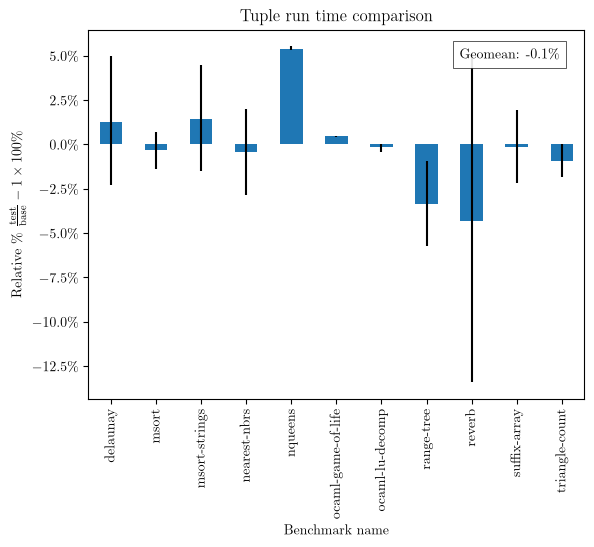

NOT saving chart to charts/tuple_mlton_size_mlton_vs_mlton.pdf


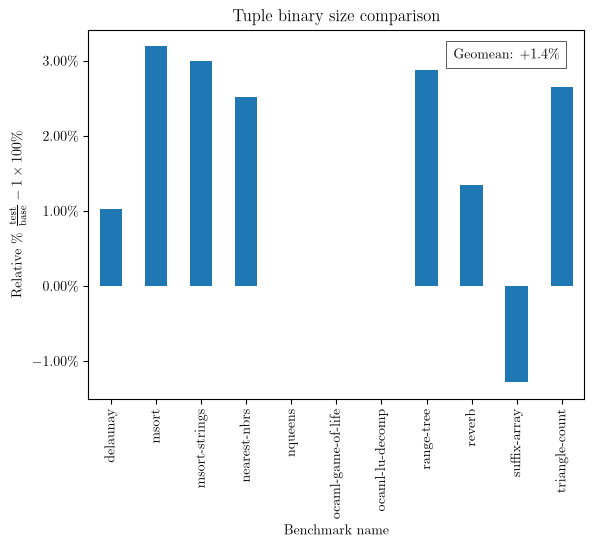

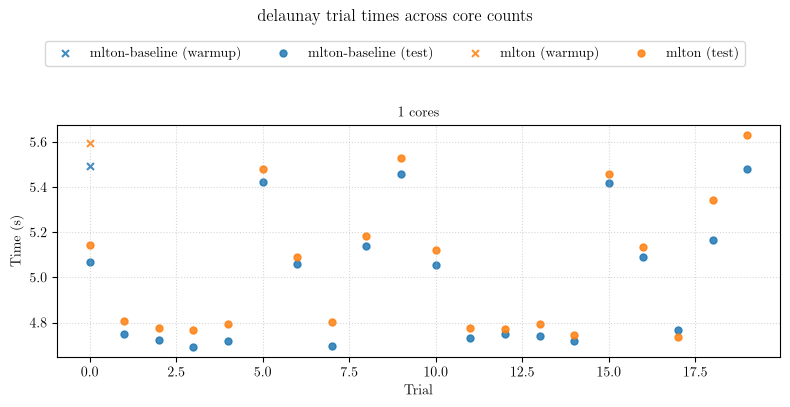

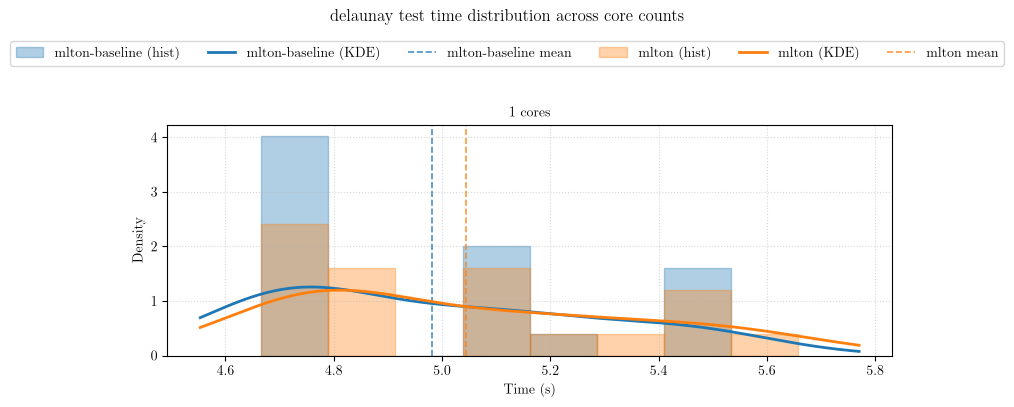

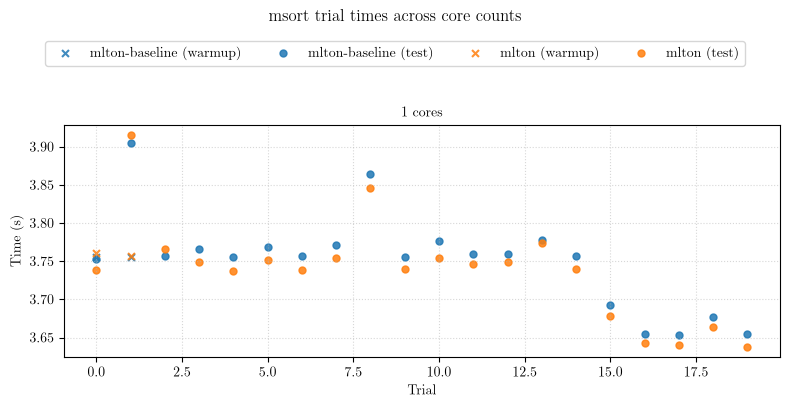

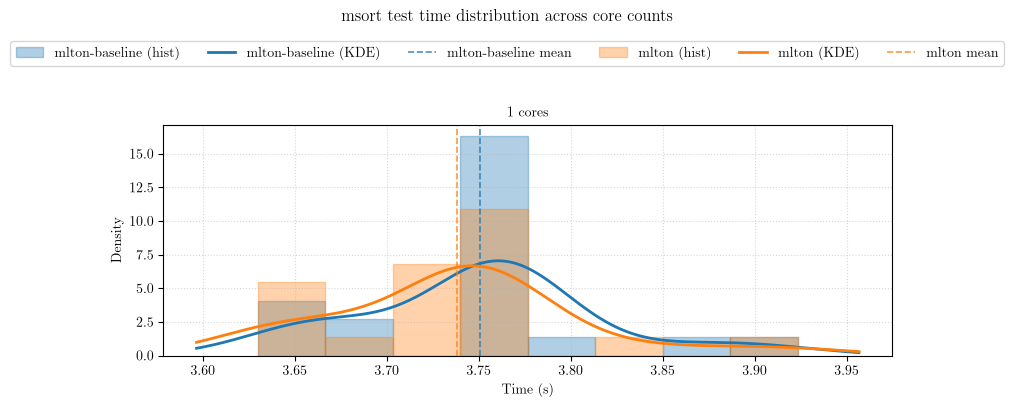

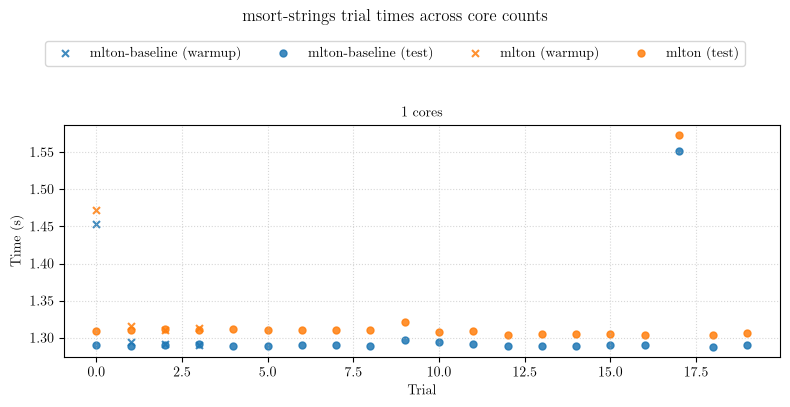

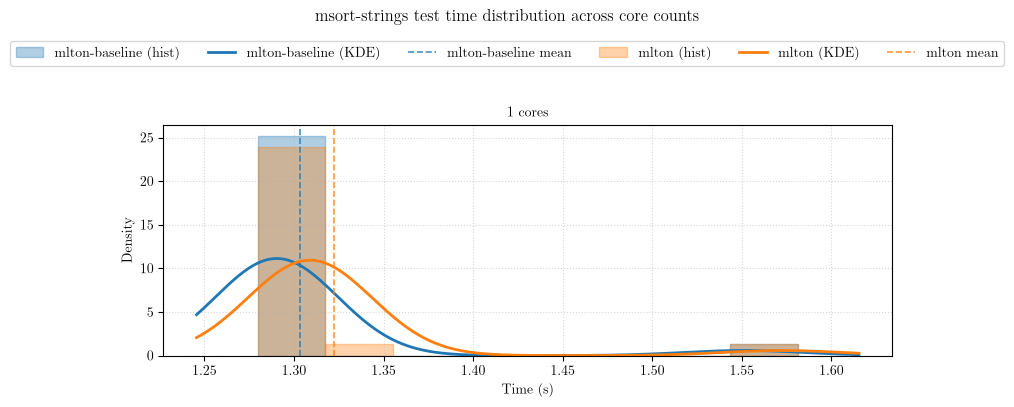

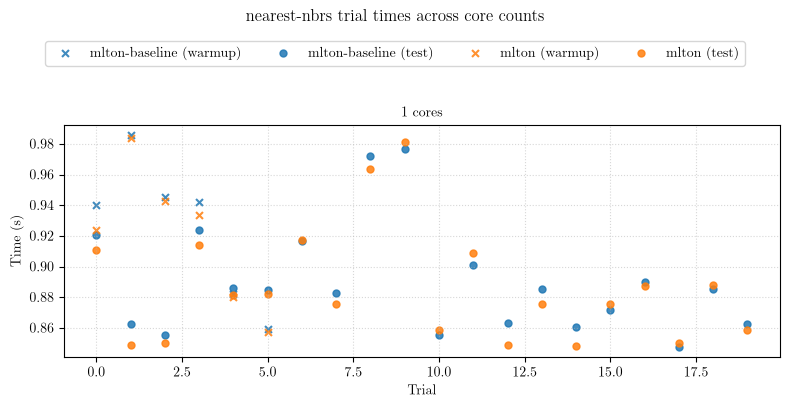

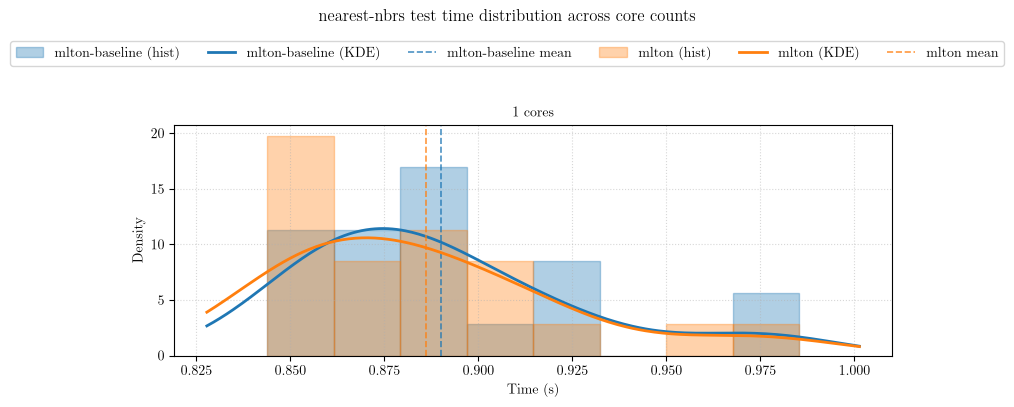

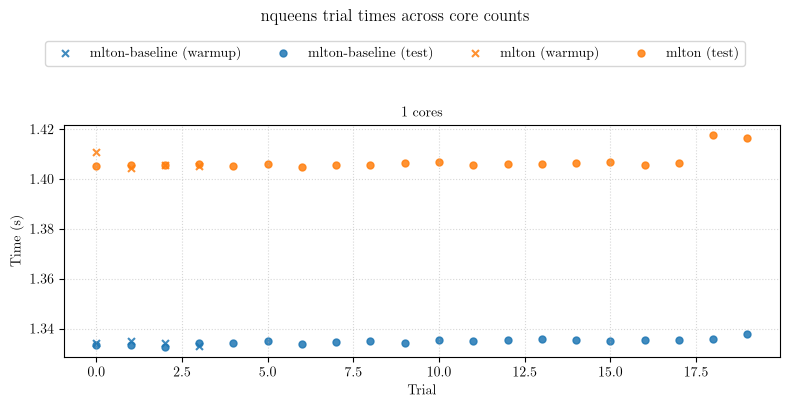

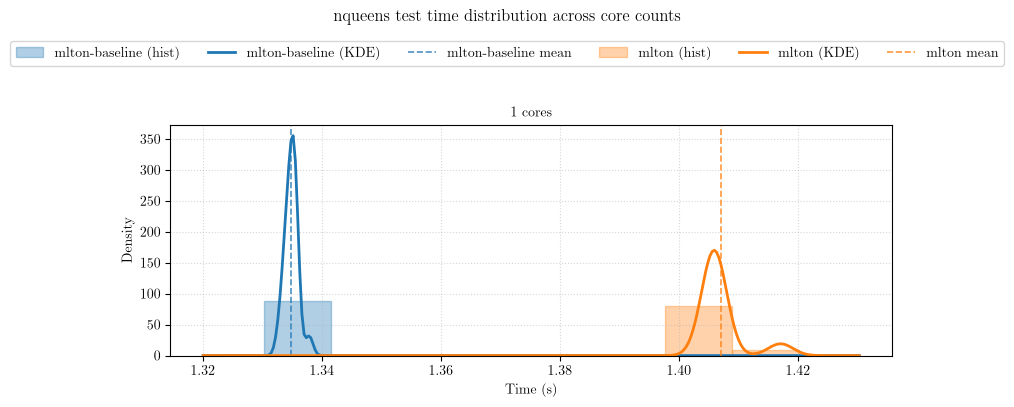

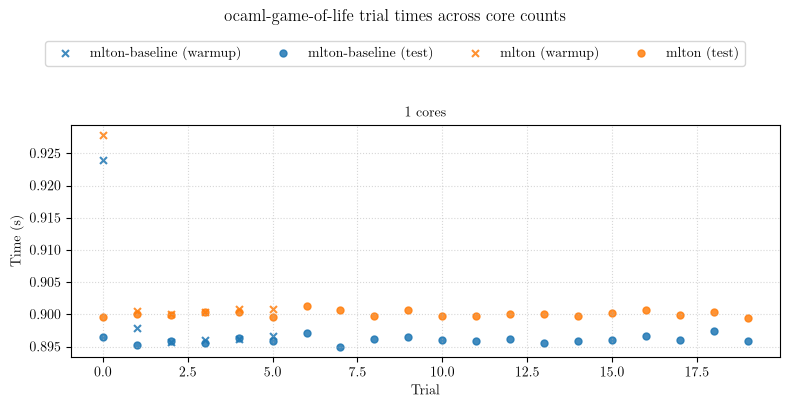

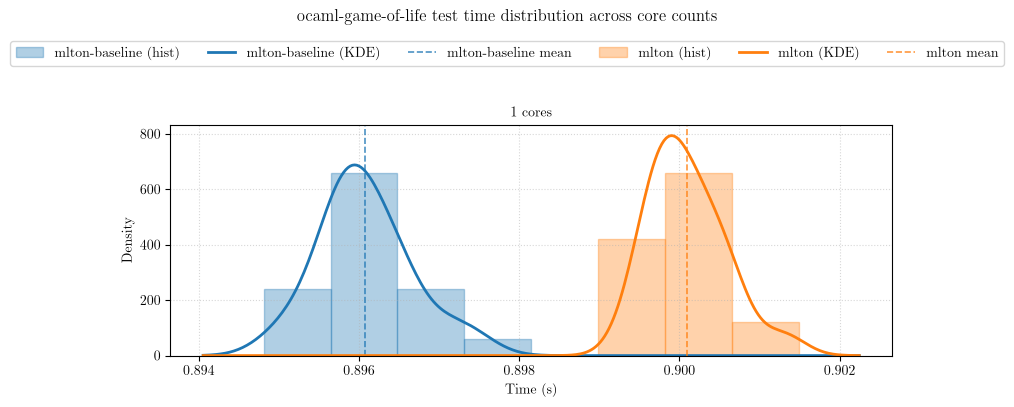

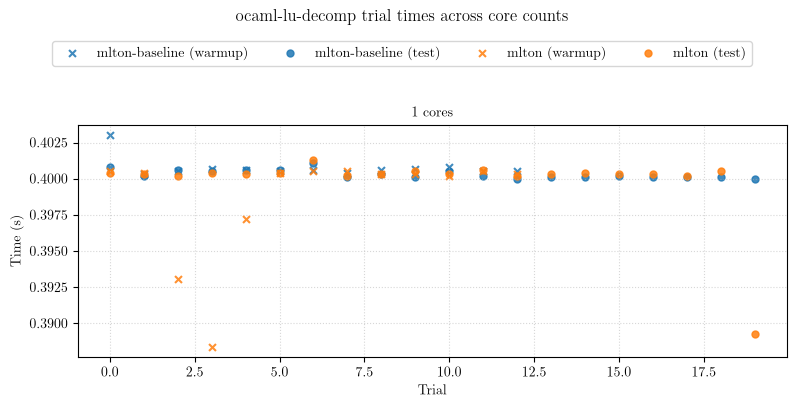

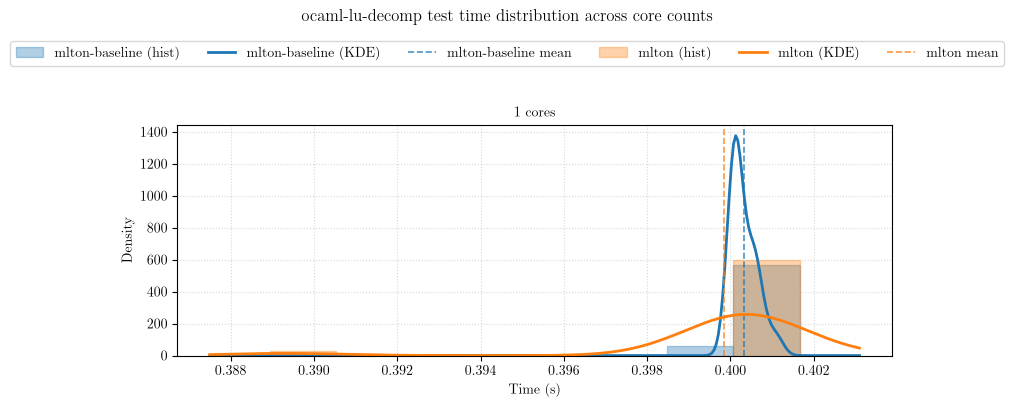

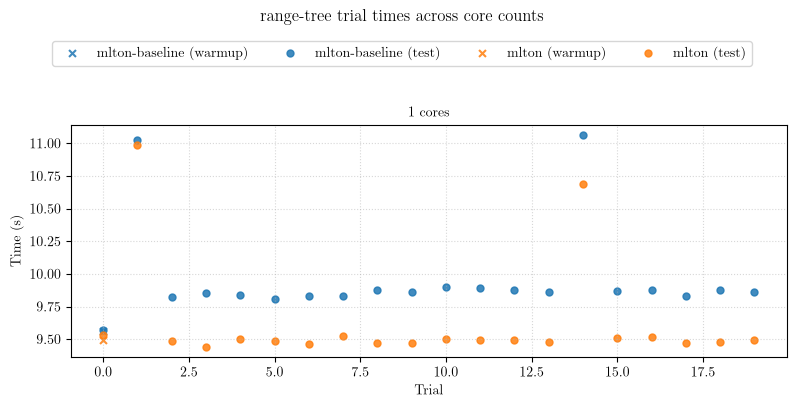

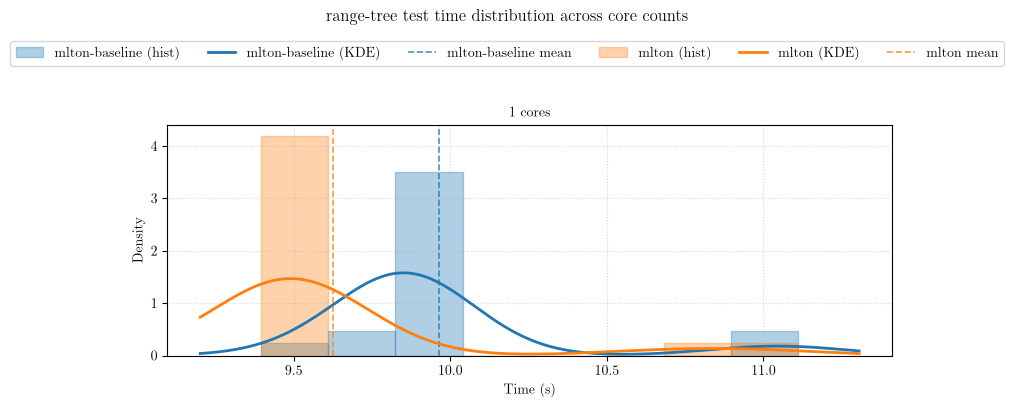

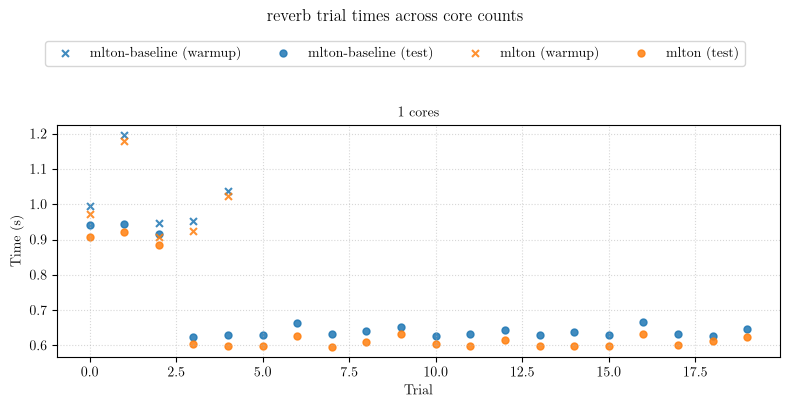

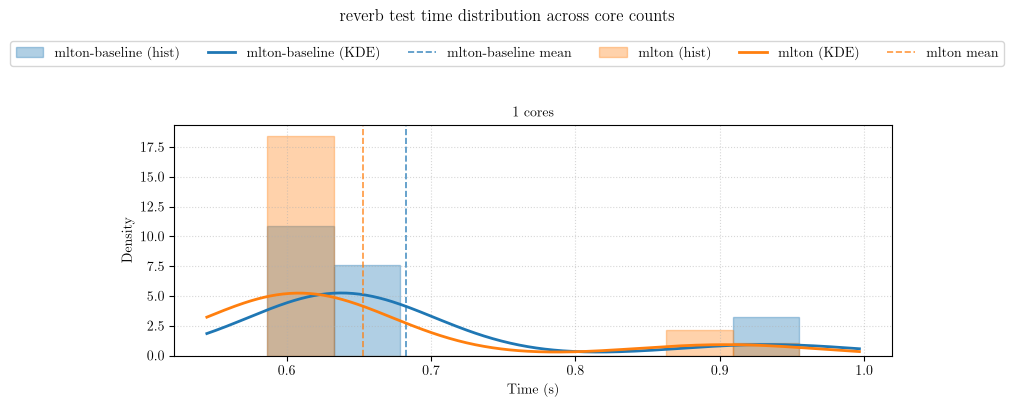

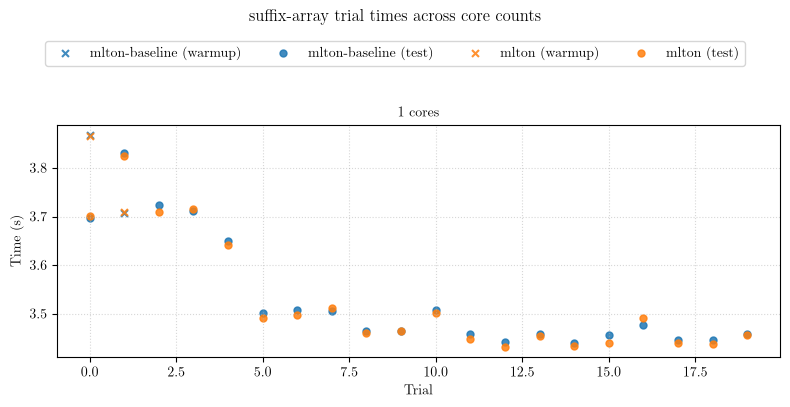

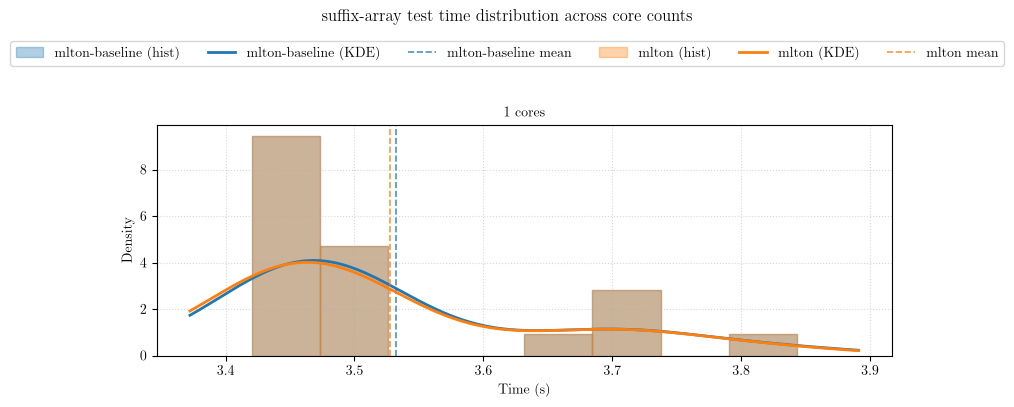

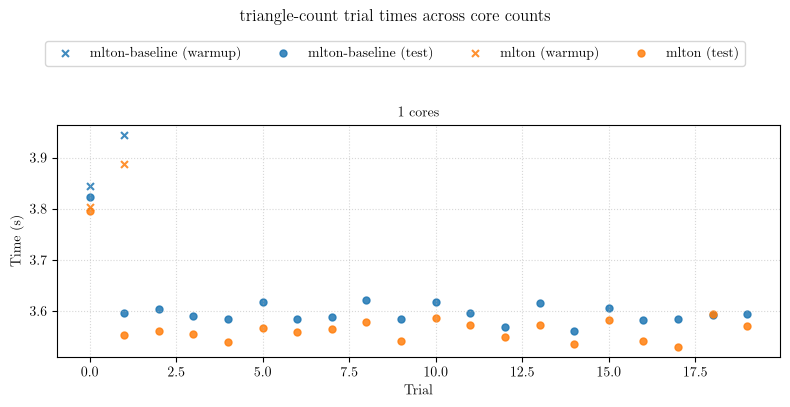

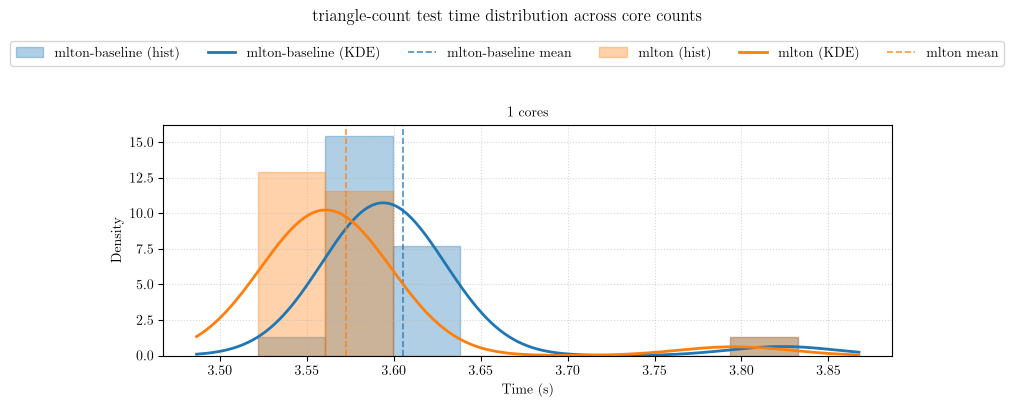

Plotting file for conapp flattening (MLton vs MLton): cc_conapp_flatten_fixed_hash:260814-000801:flattening-tests:dfcc9e1798eddbe9a3d884b806fa2a946f27000d:260814-000801.processed.jsonl
NOT saving chart to charts/conapp_parallel_ml_bench_run_mlton_vs_mlton.pdf


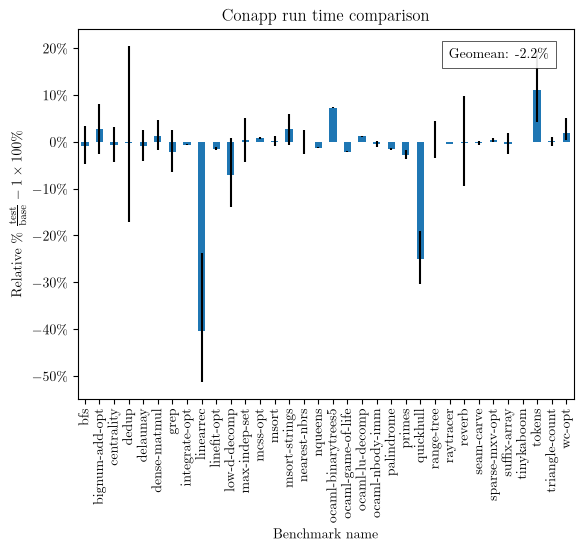

NOT saving chart to charts/conapp_mlton_size_mlton_vs_mlton.pdf


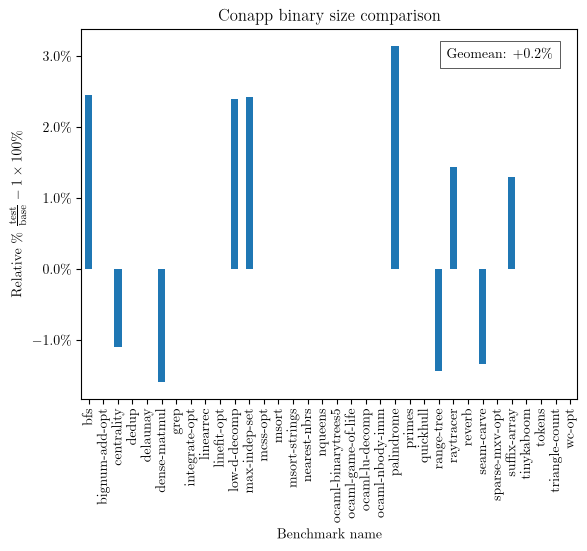

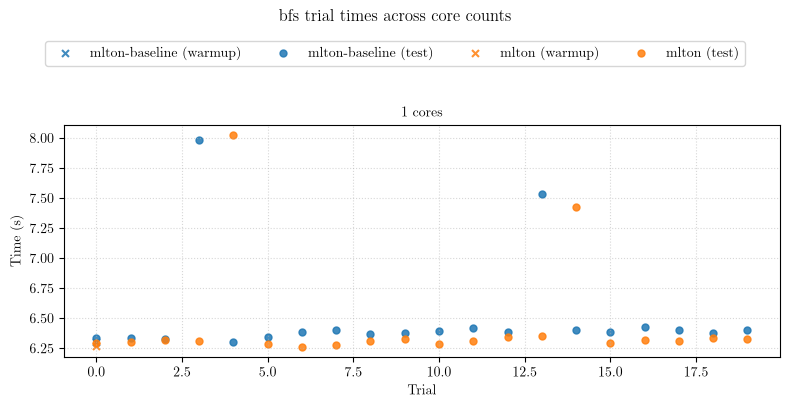

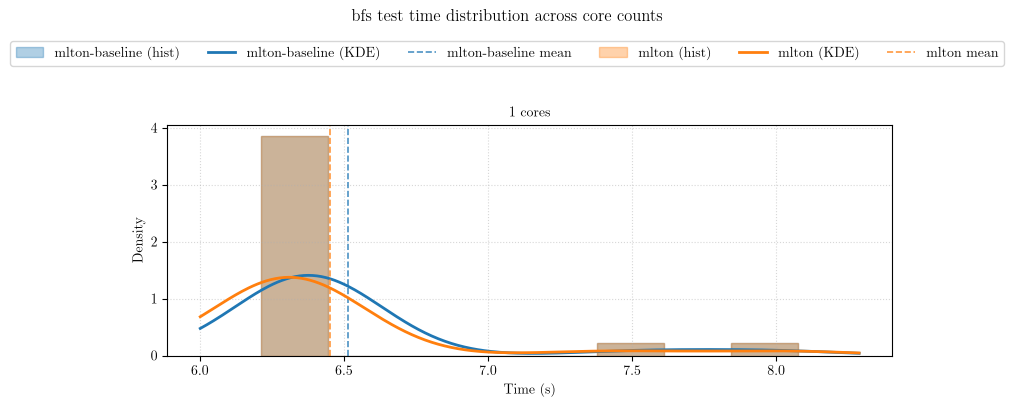

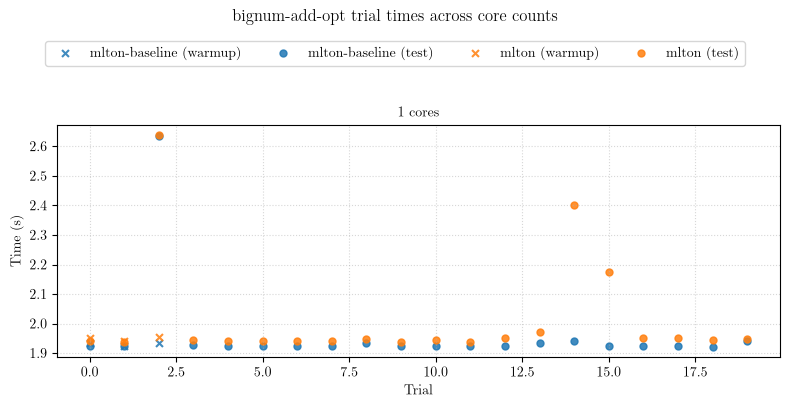

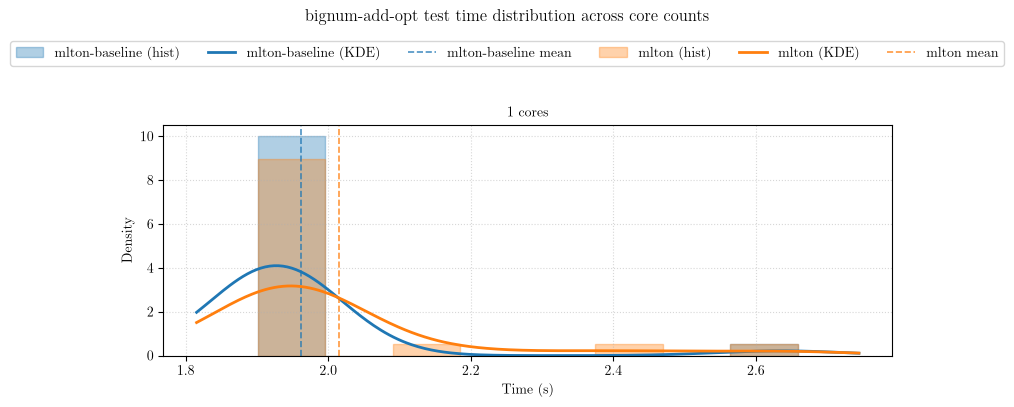

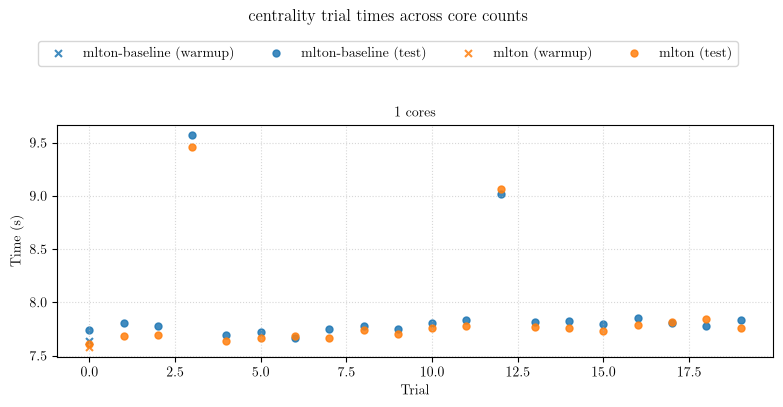

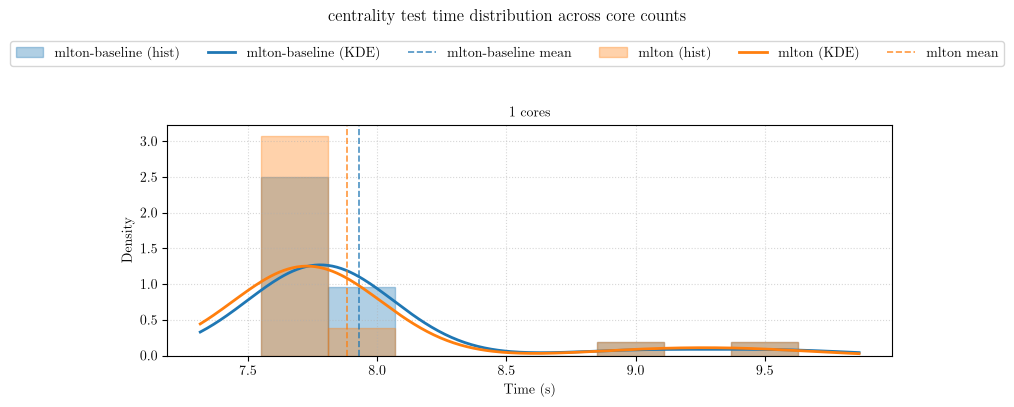

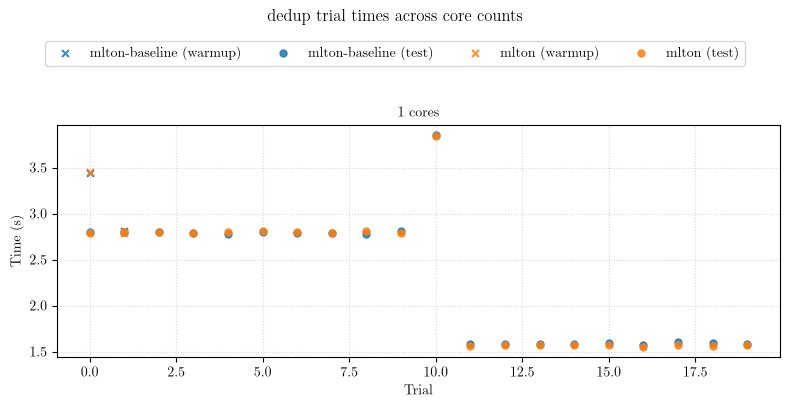

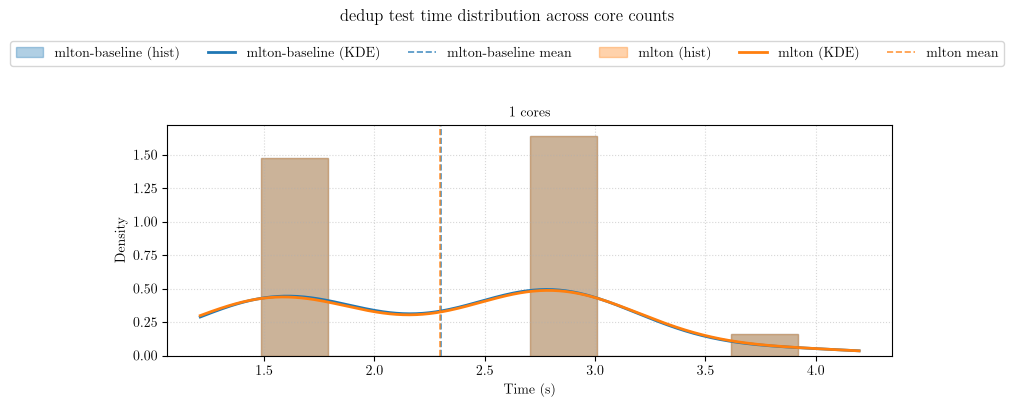

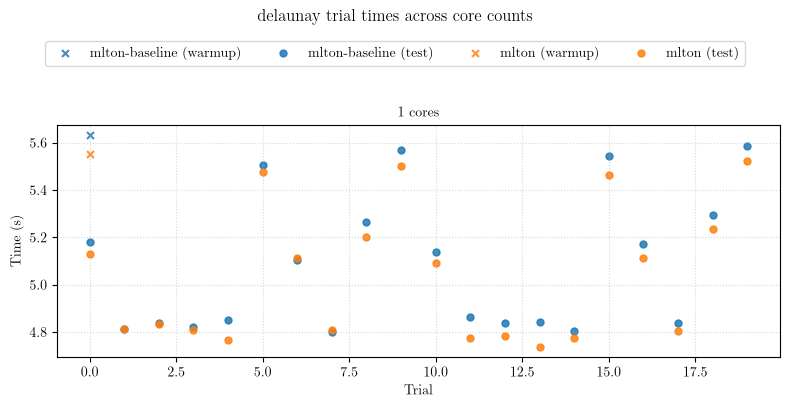

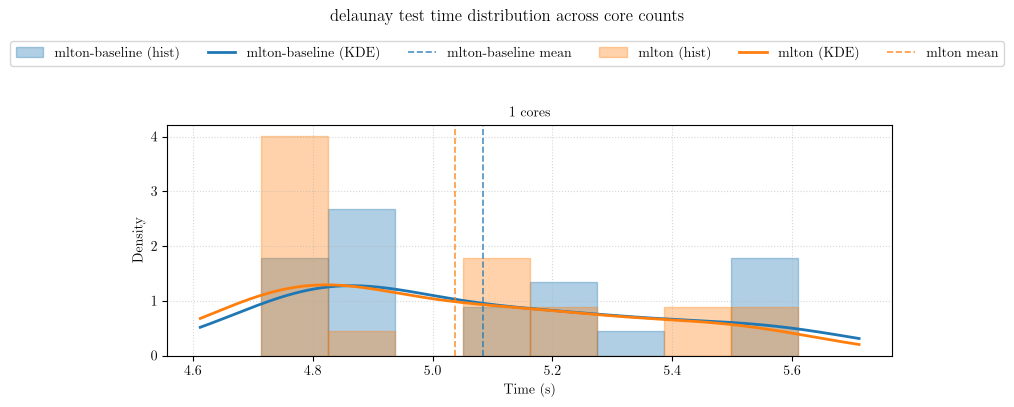

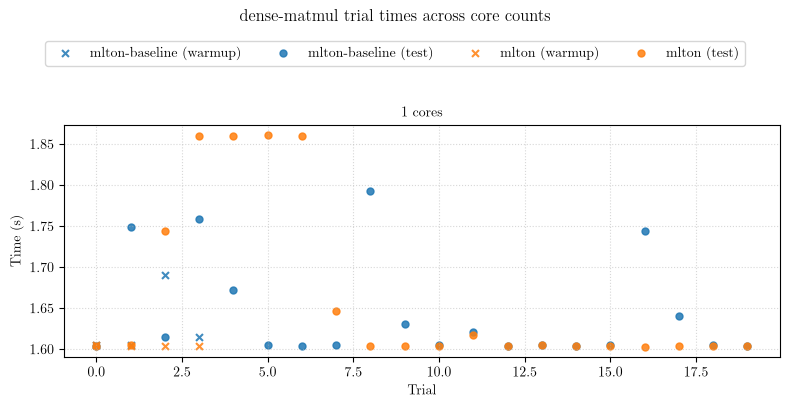

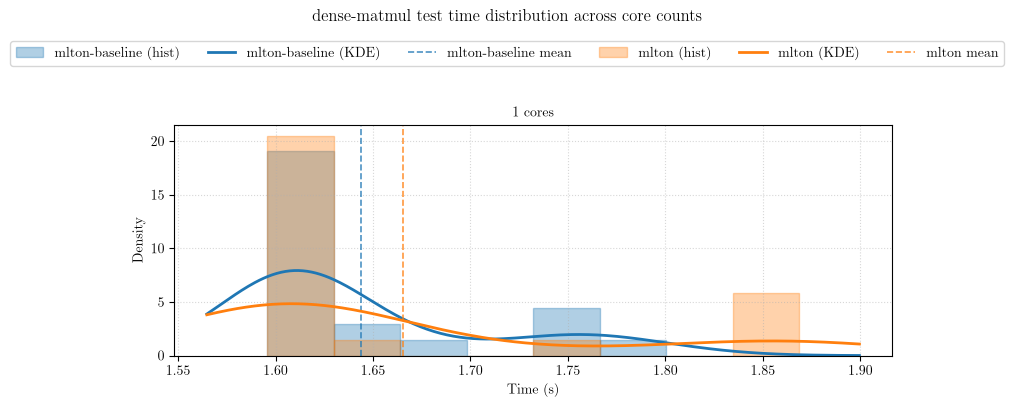

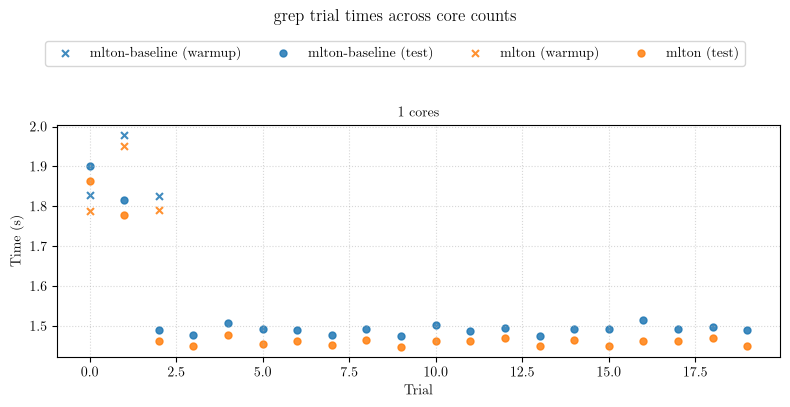

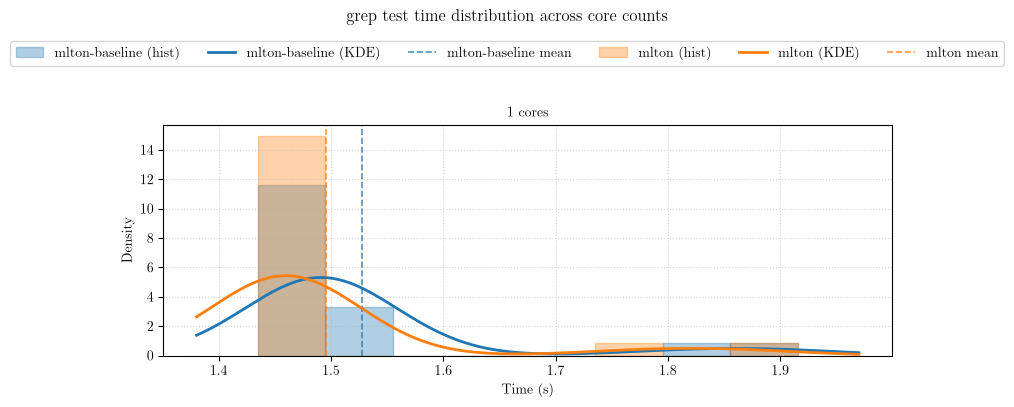

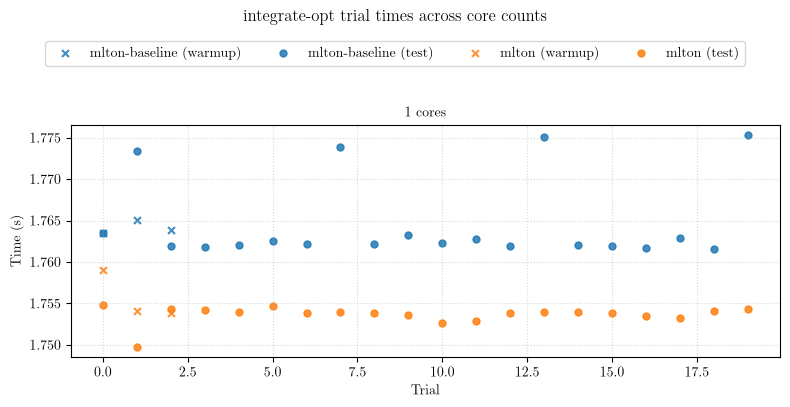

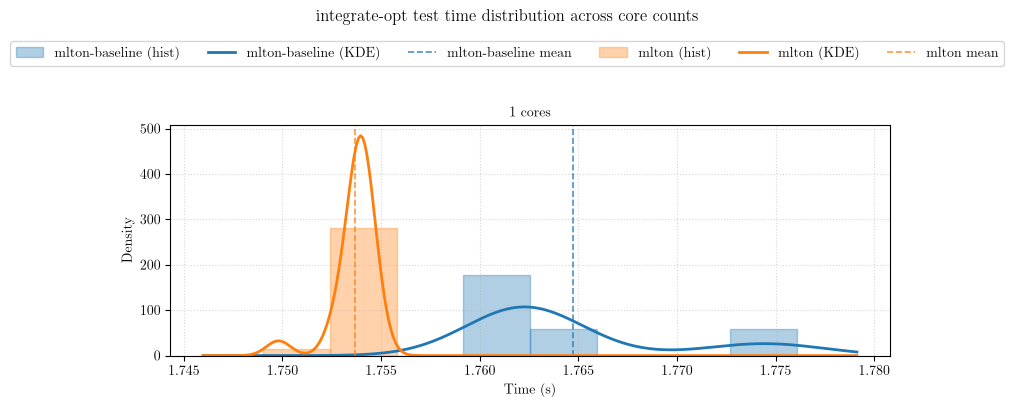

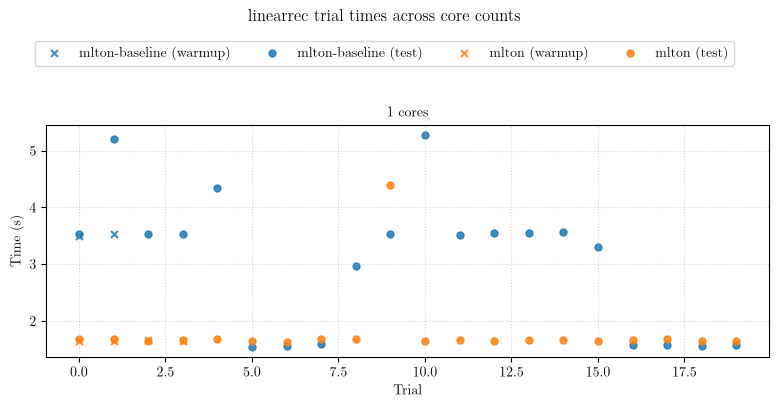

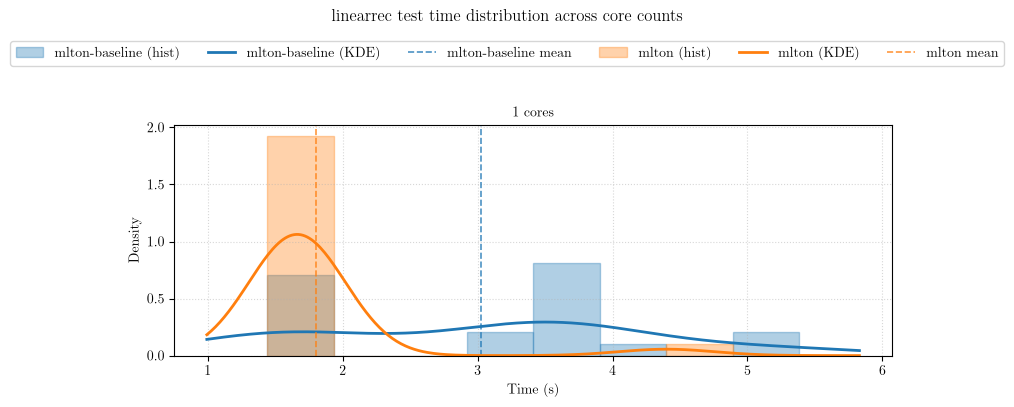

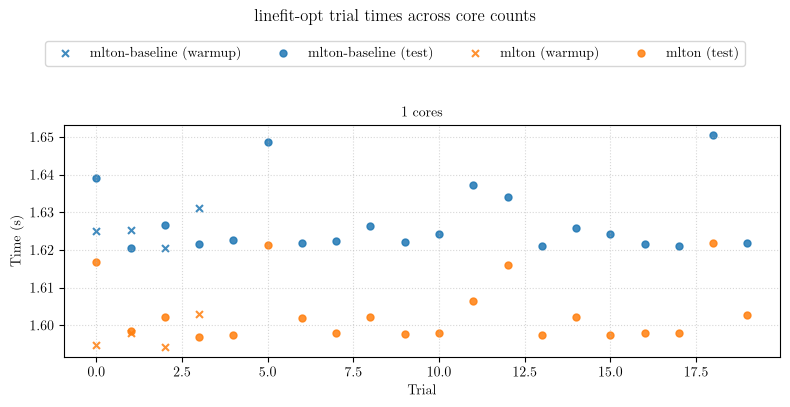

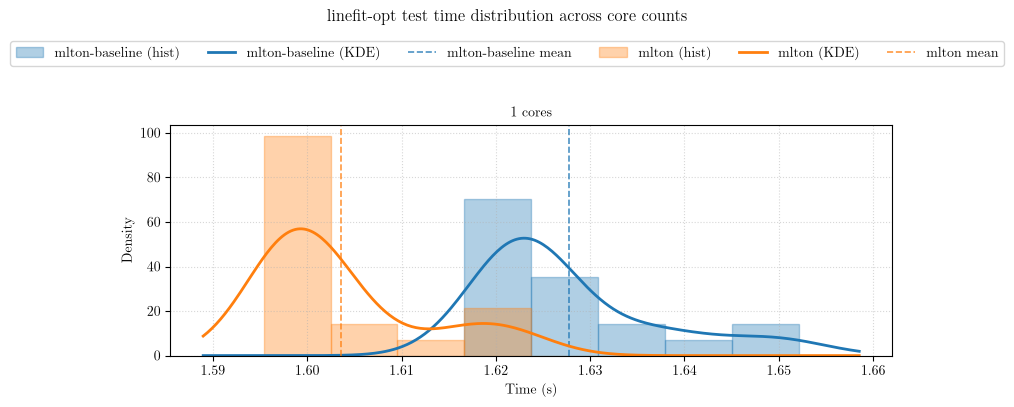

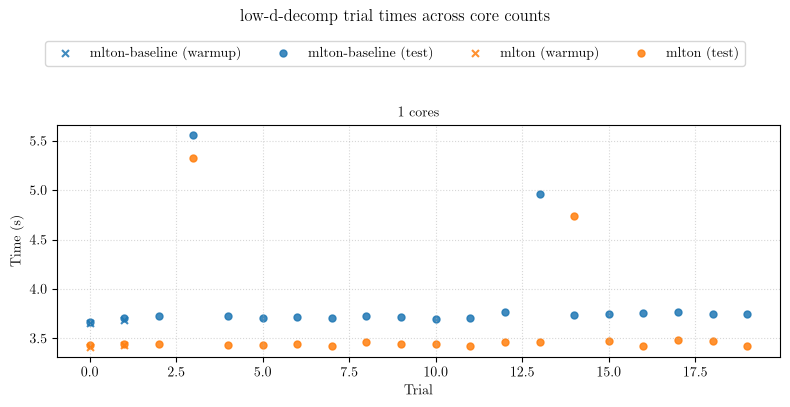

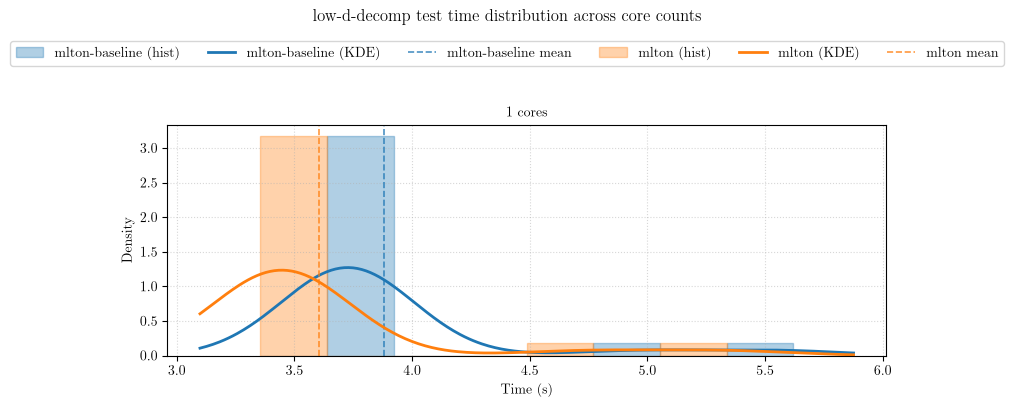

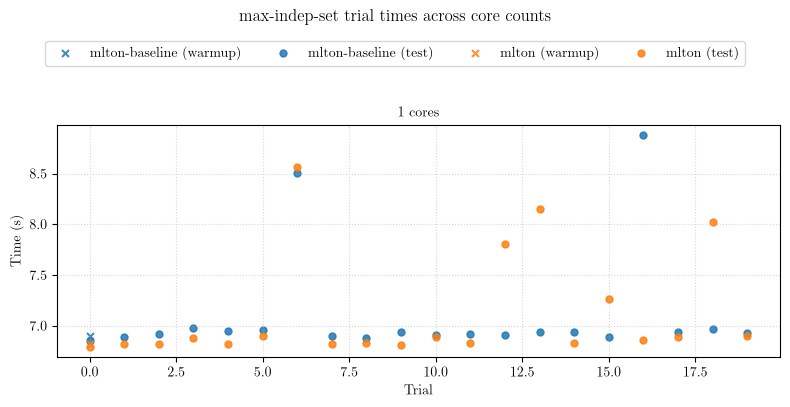

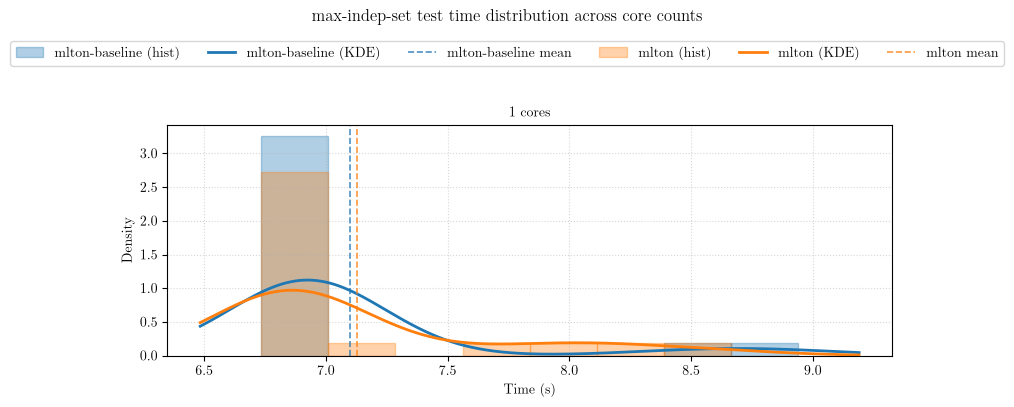

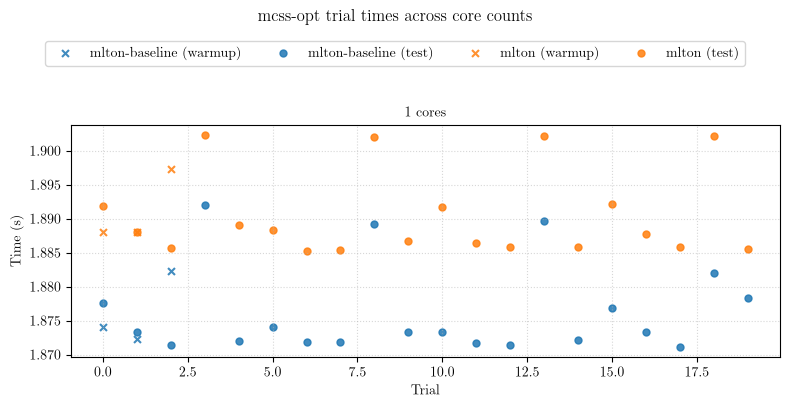

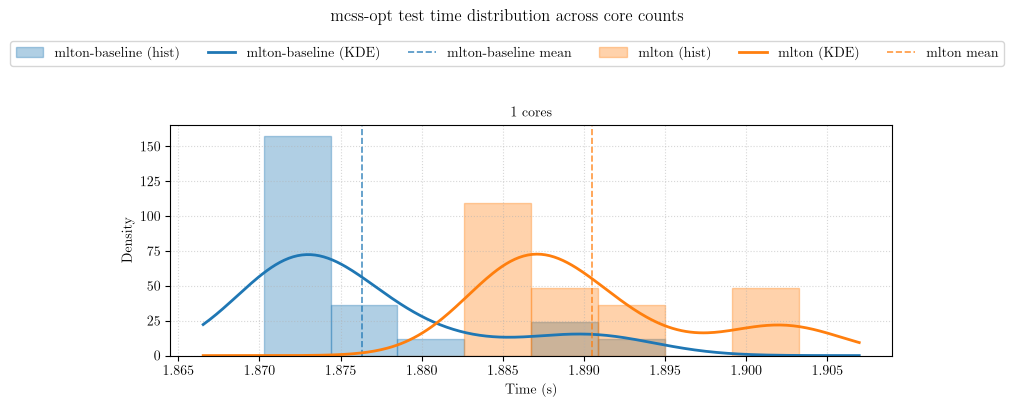

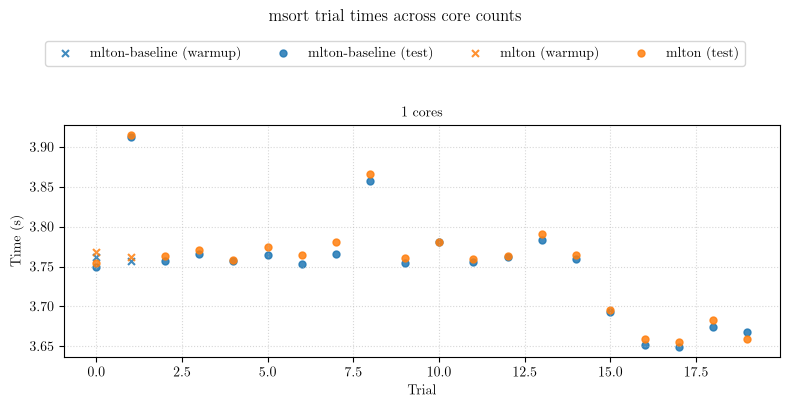

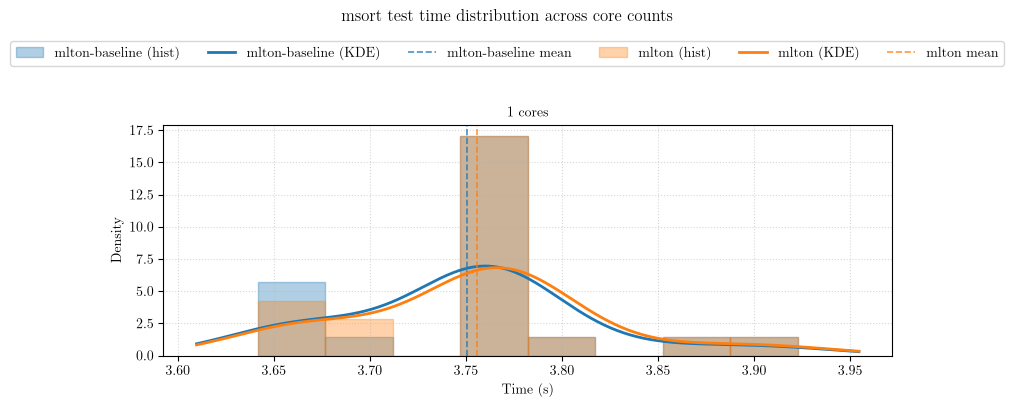

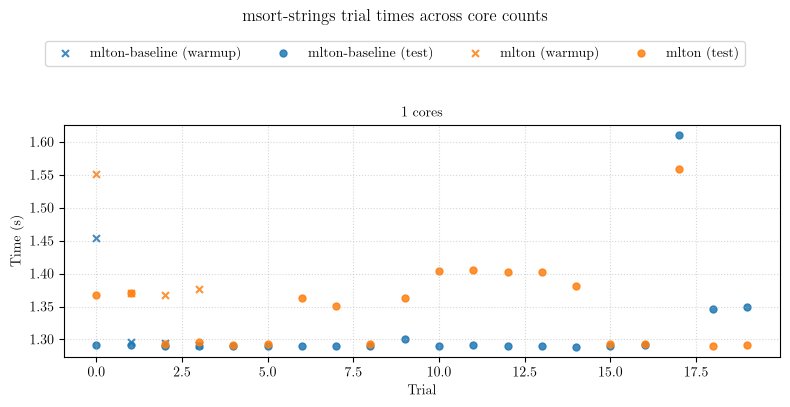

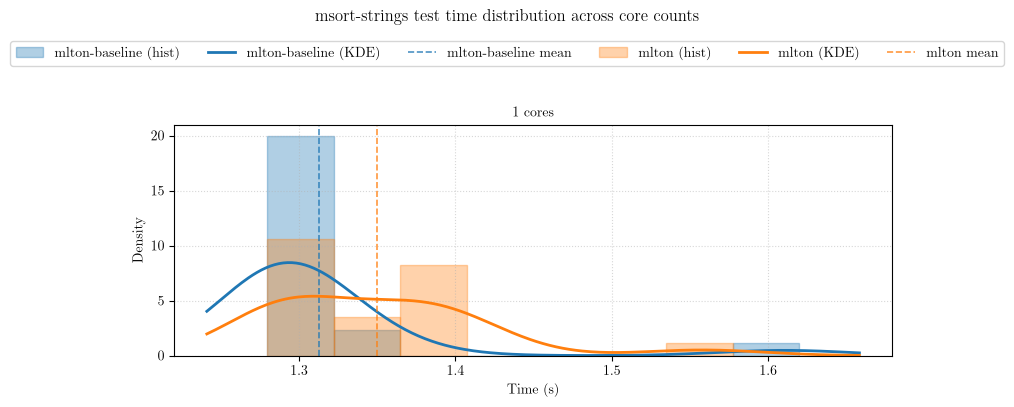

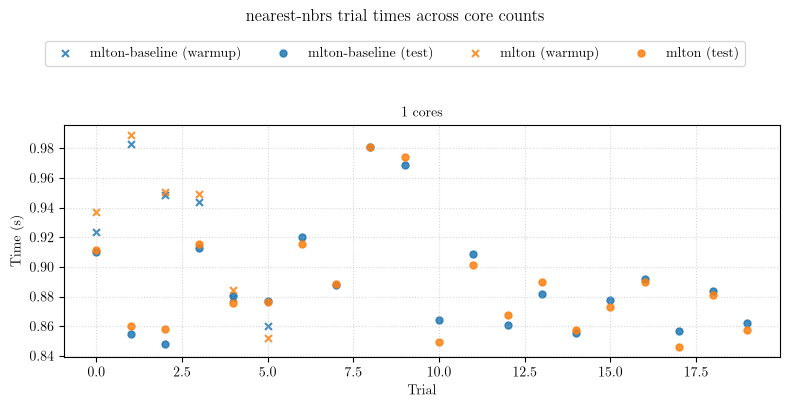

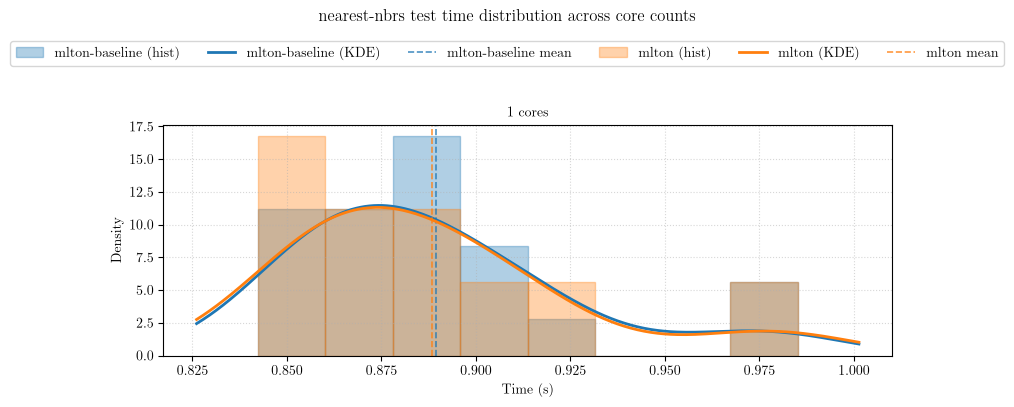

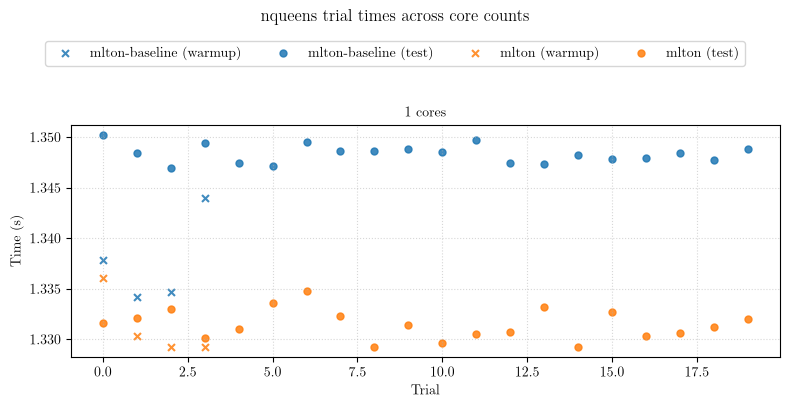

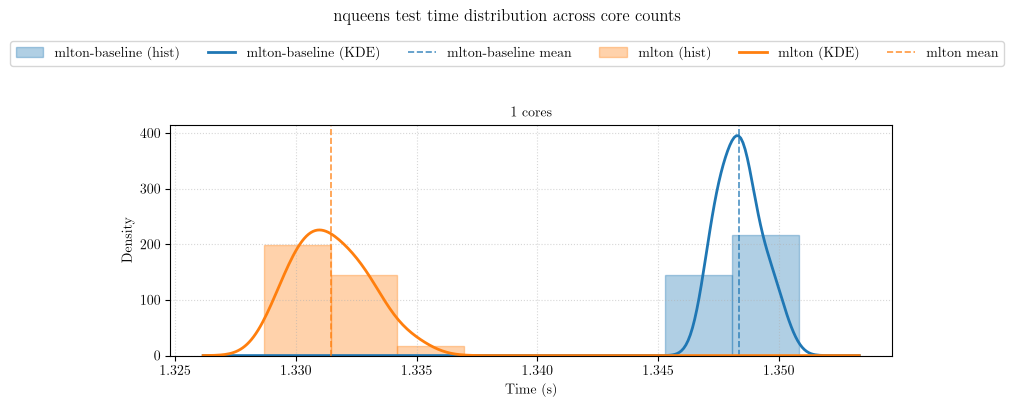

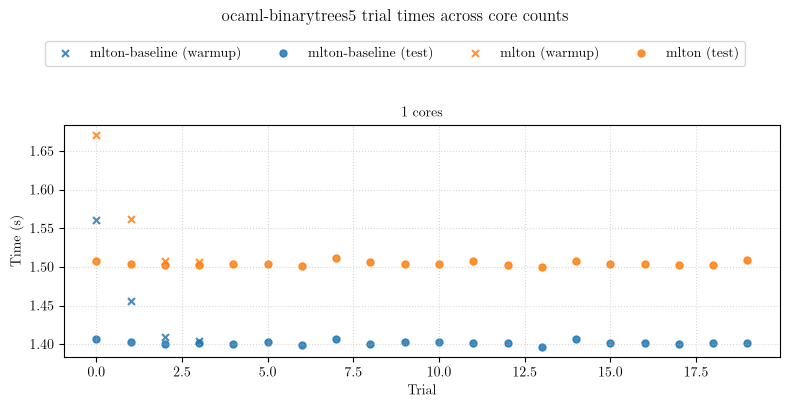

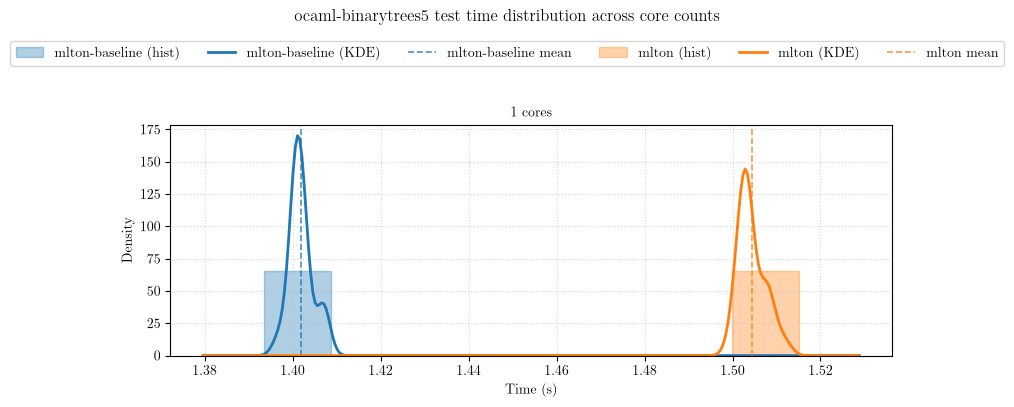

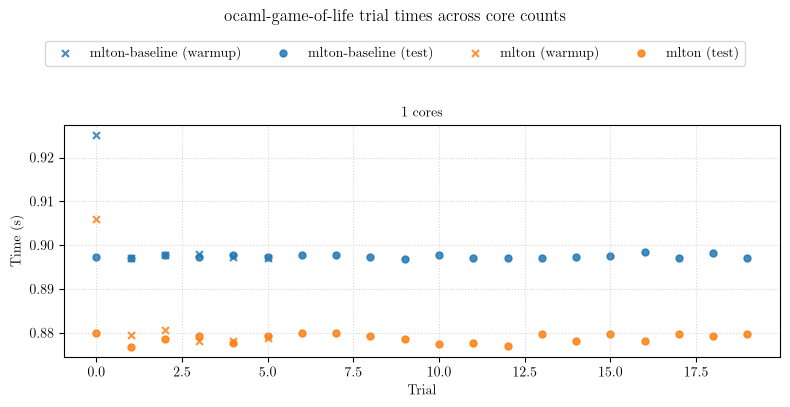

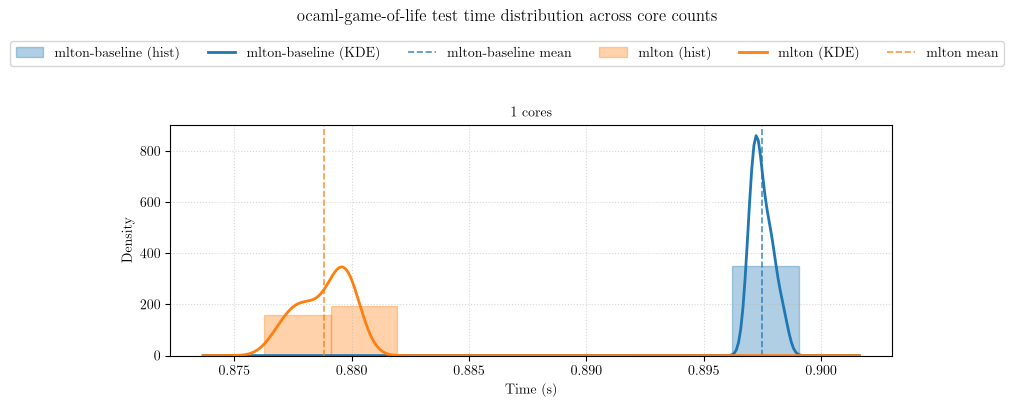

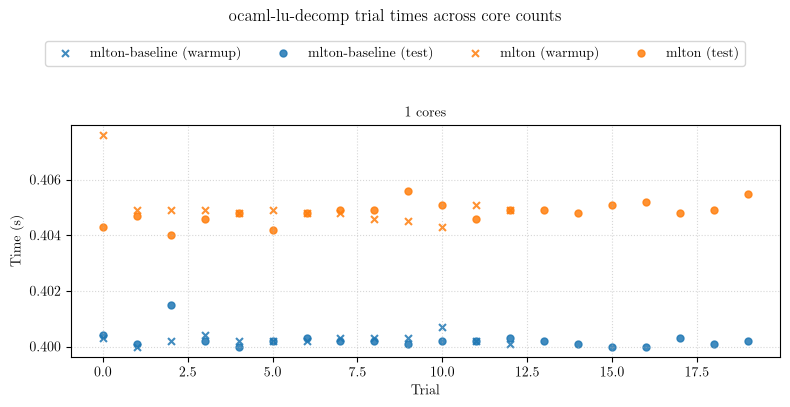

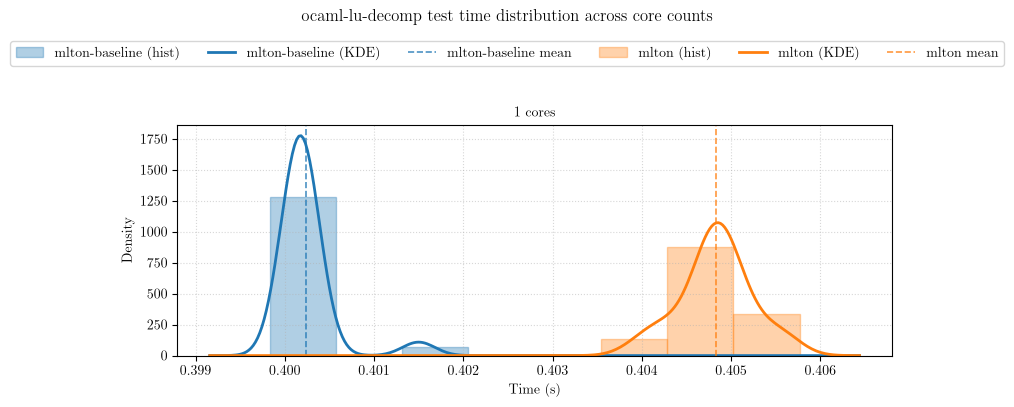

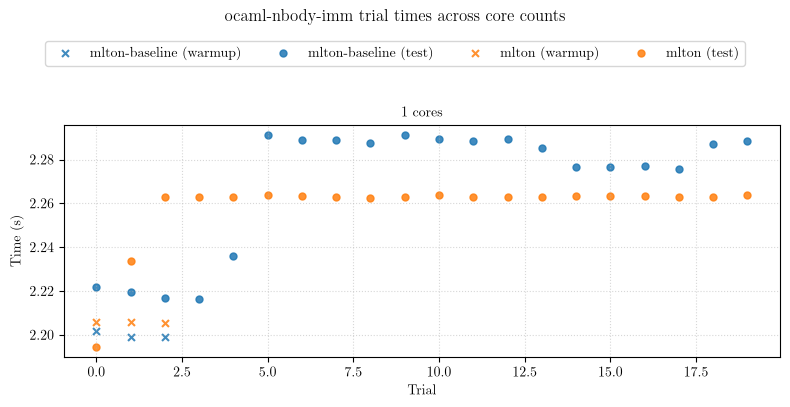

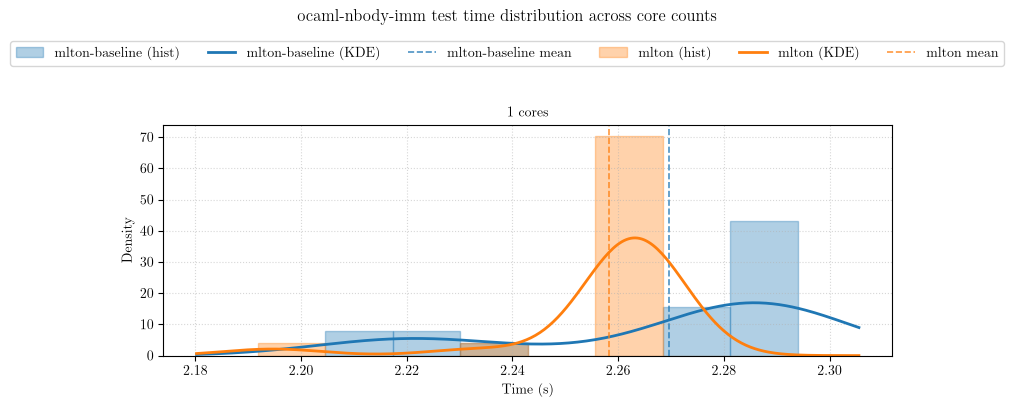

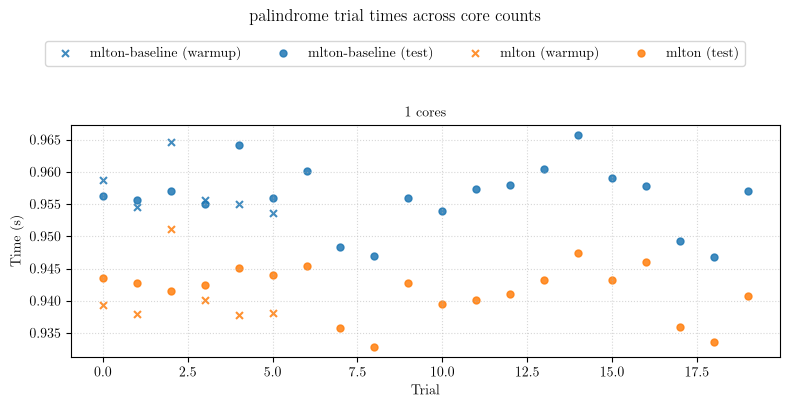

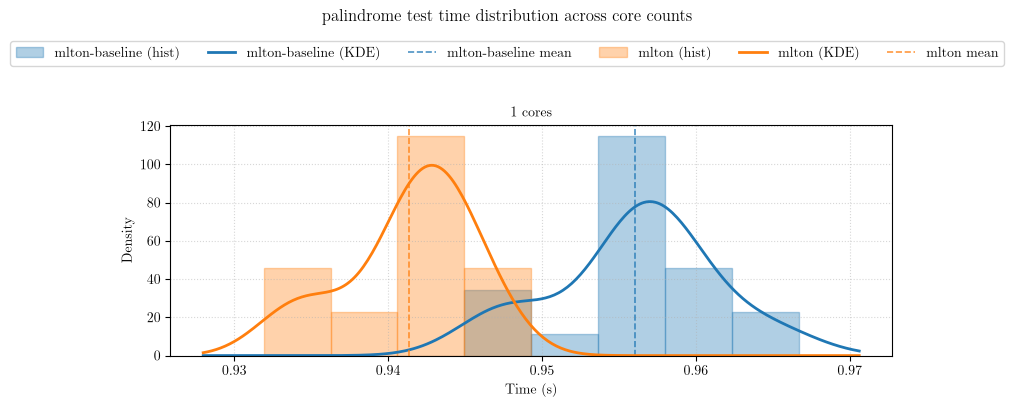

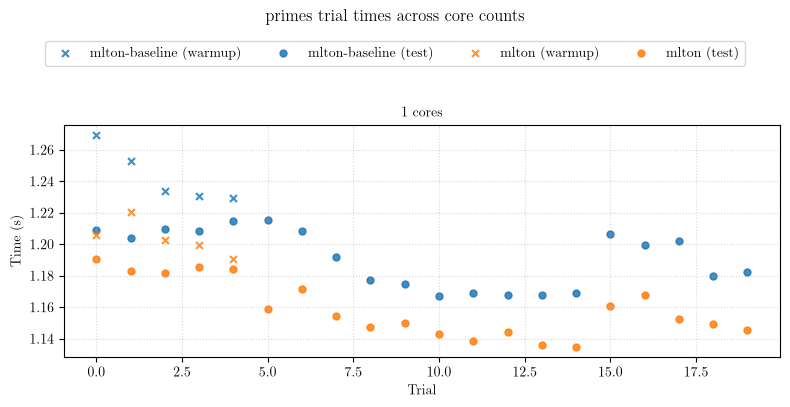

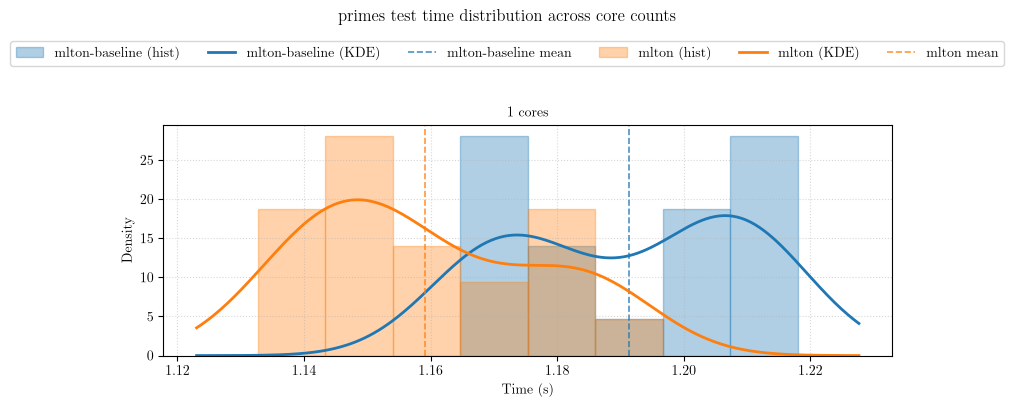

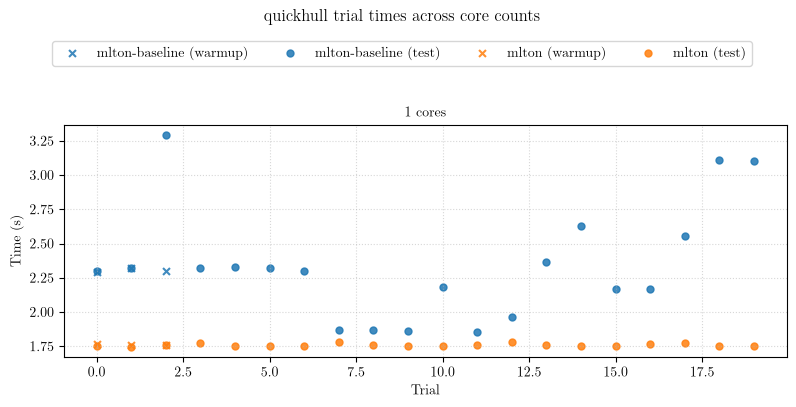

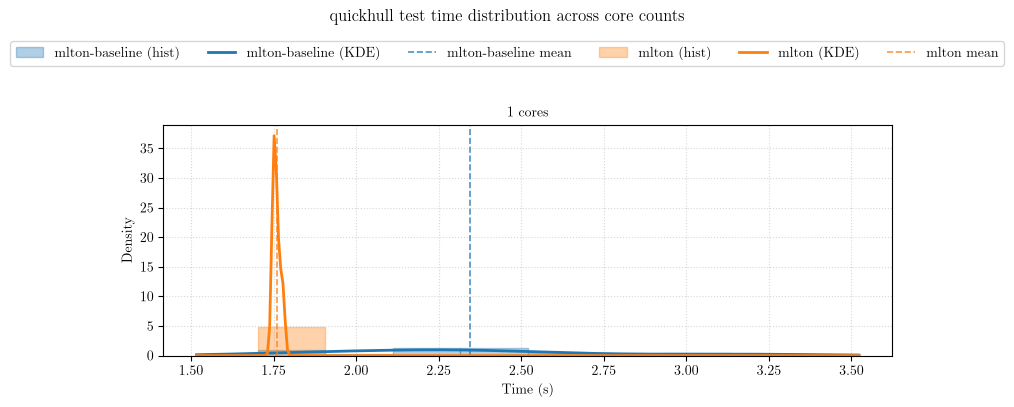

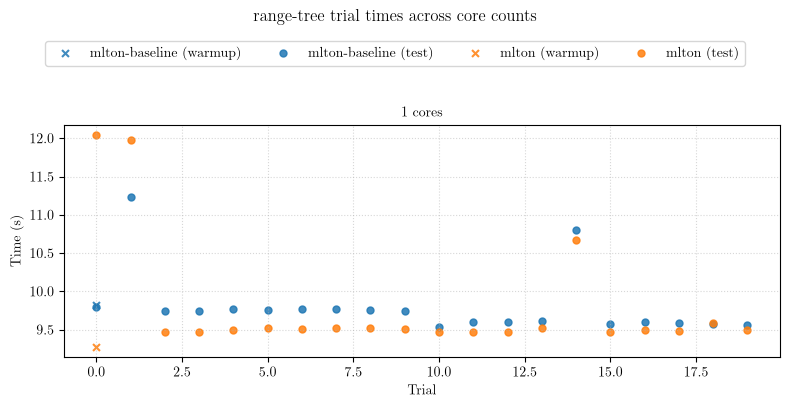

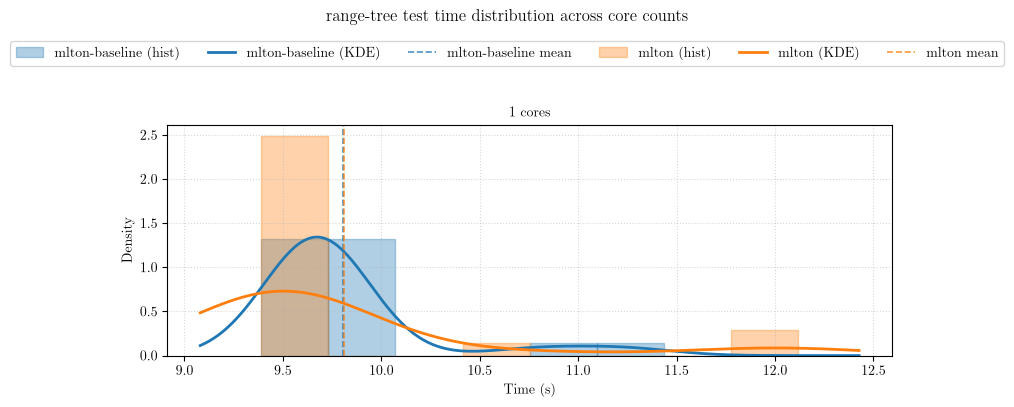

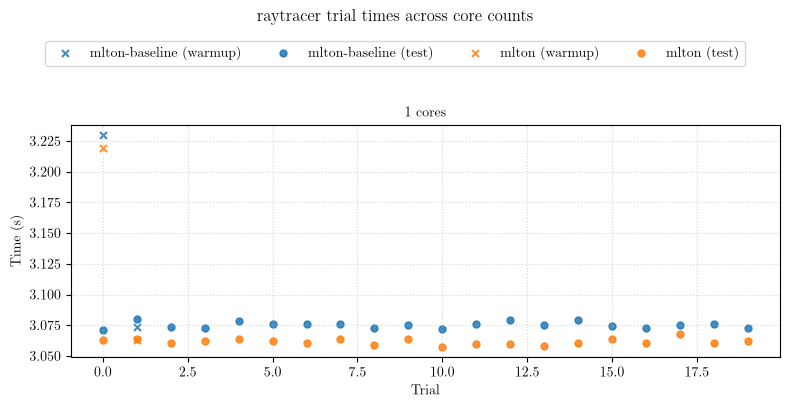

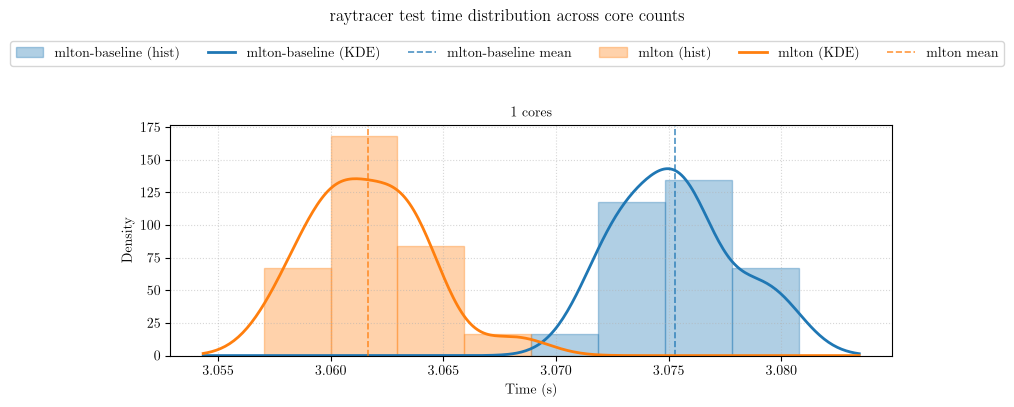

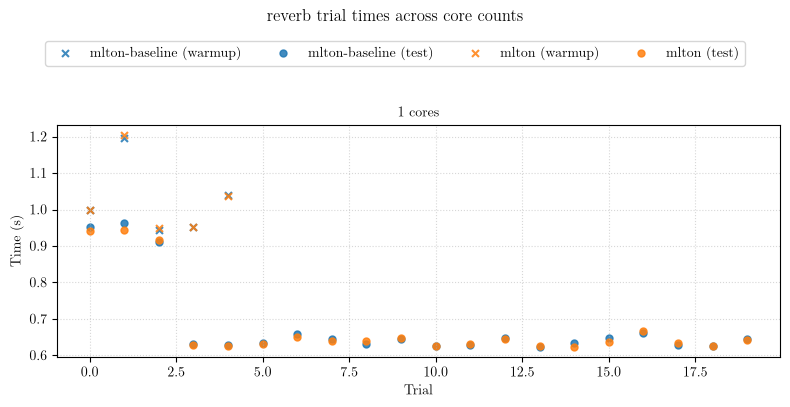

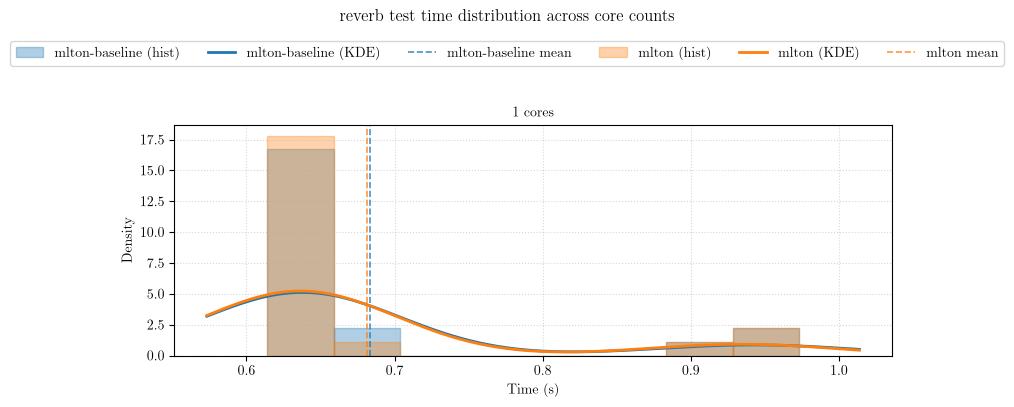

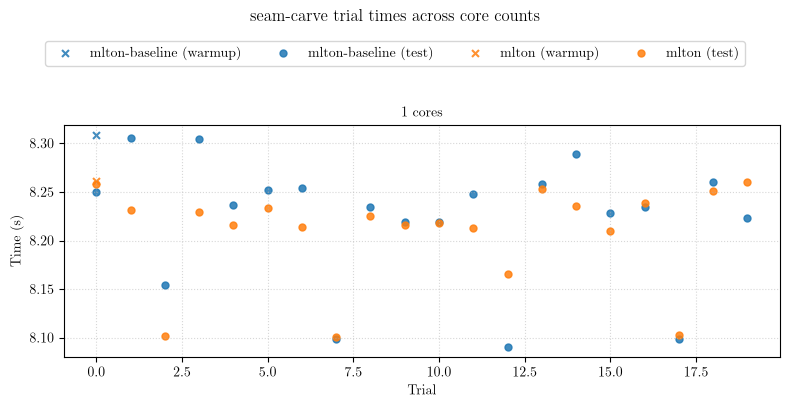

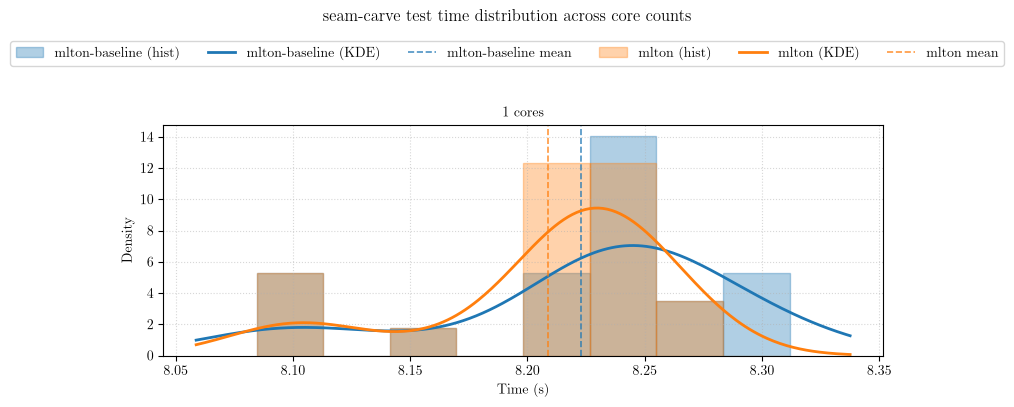

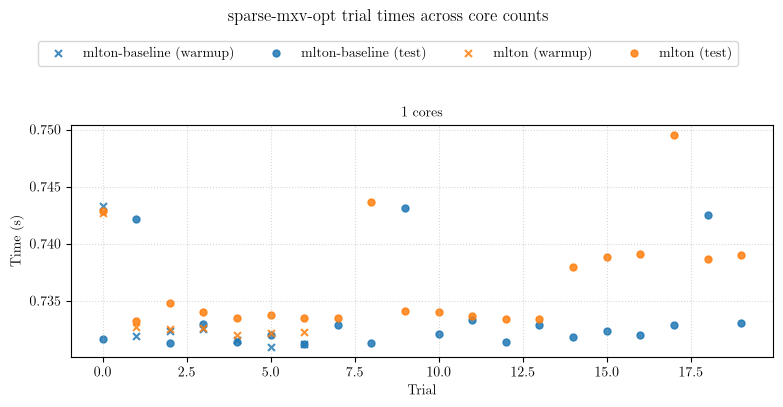

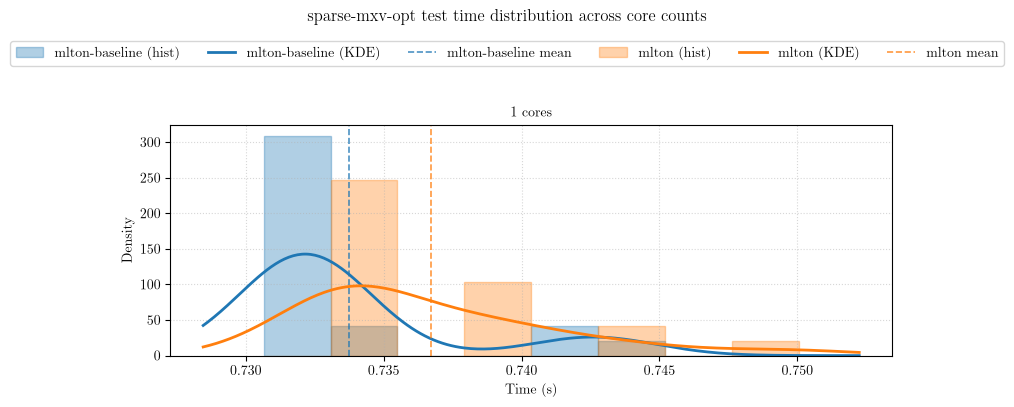

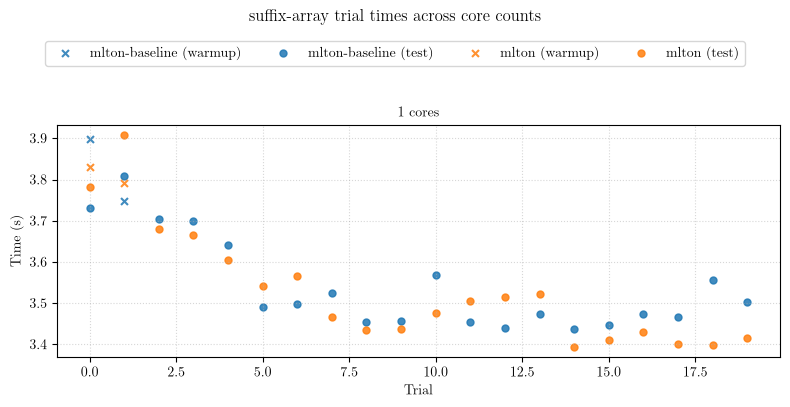

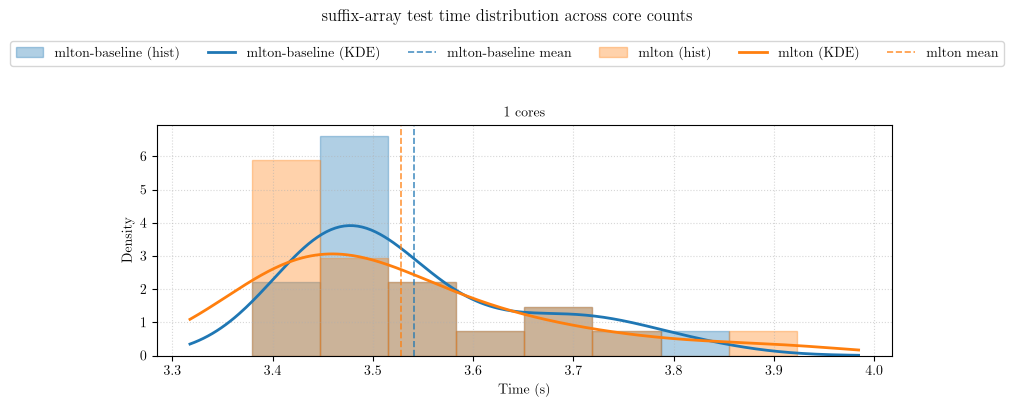

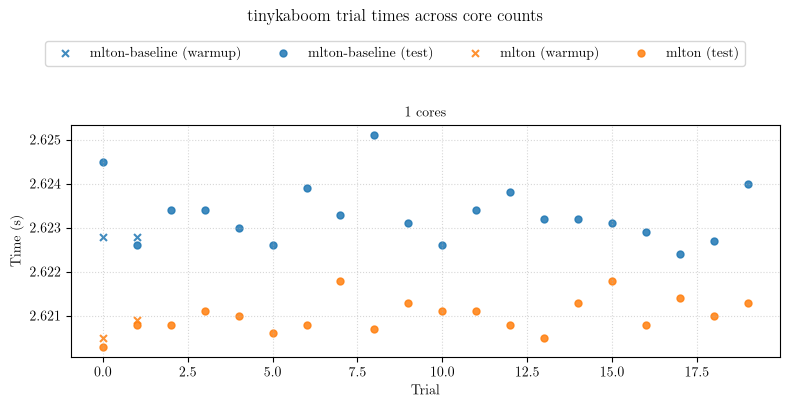

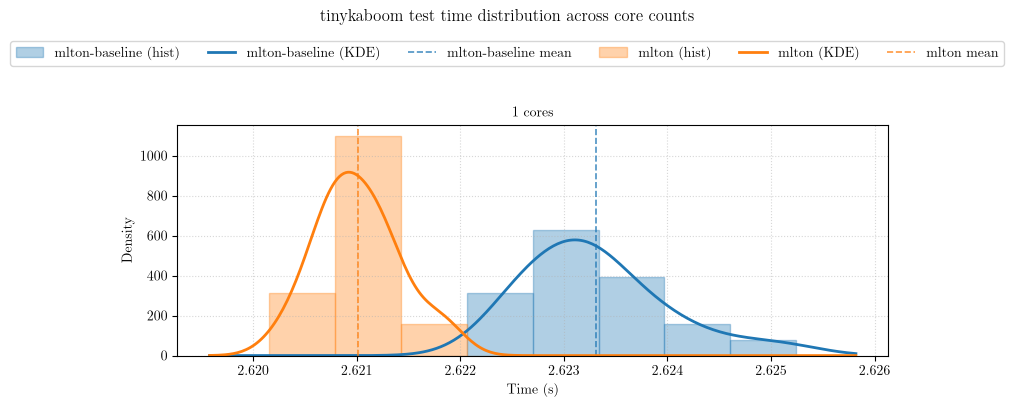

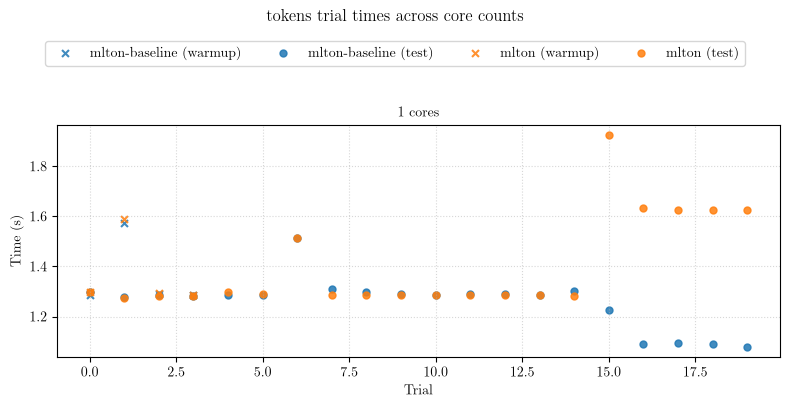

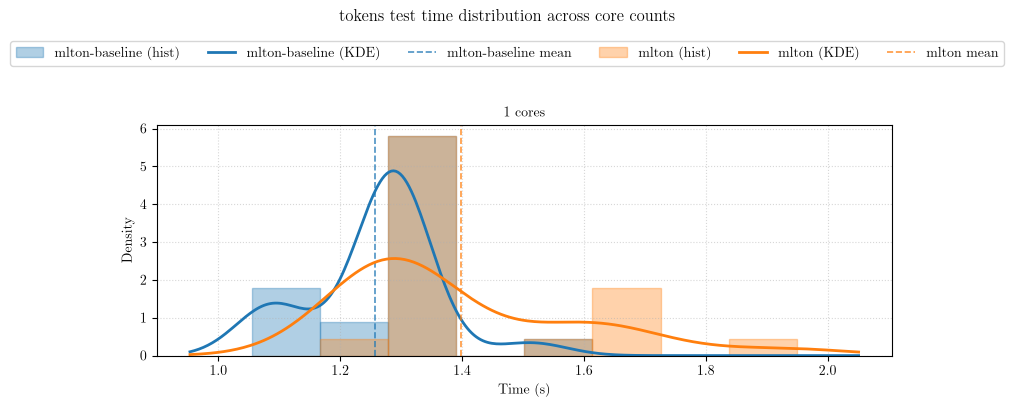

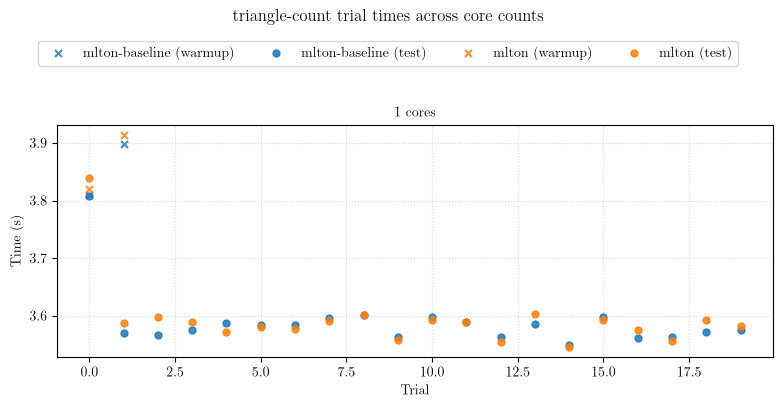

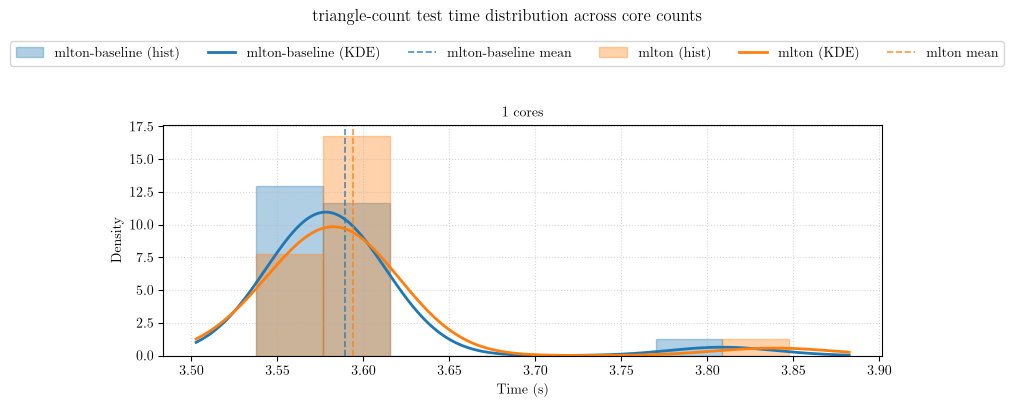

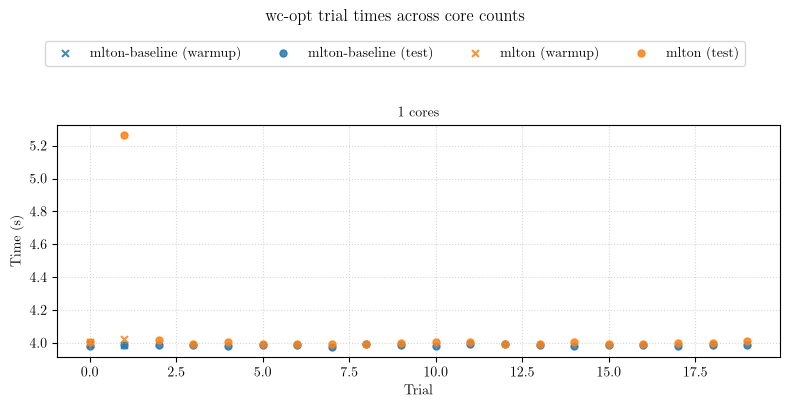

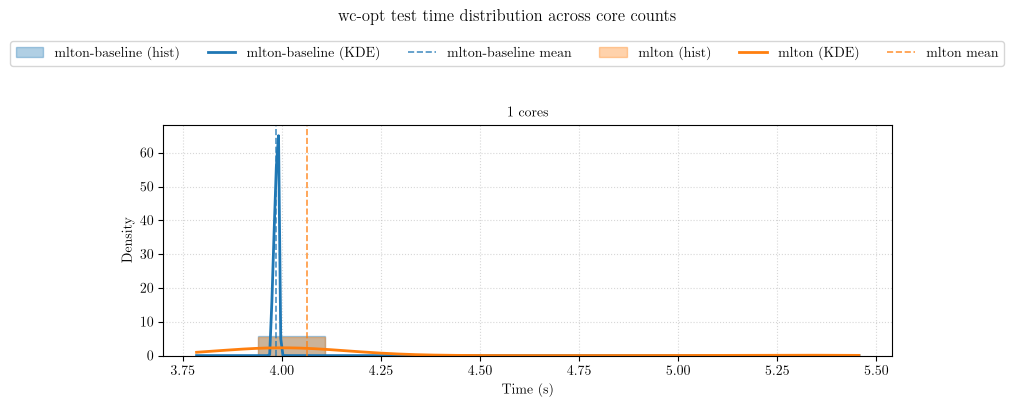

In [4]:
plot_parallel_bench_tuple_mlton_vs_mlton()
plot_parallel_bench_conapp_mlton_vs_mlton()
